In [8]:
# ════════════════════════════════════════════════════════════════════════
# SNIPPET 1 — Setup · Config · Hardware probe
# Ablation redo | Zero-Shot Nutrient & Quantity Association | M. Hamada
# ════════════════════════════════════════════════════════════════════════
"""Imports, project-root resolution, logging, the single `ablation_config`
object, path handles, and a runtime hardware probe.

The probe runs on THIS machine, so every later pipeline can report the exact
CPU / GPU each component used (the per-component manifest is assembled in the
engine cell, Snippet 2)."""

import os
import sys
import json
import time
import platform
import logging
import warnings
import importlib.util
from pathlib import Path
from collections import Counter, defaultdict
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Dict, Any, Tuple, Callable

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown, Image as IPImage


# ── Project root — walk up from CWD for the data/ + src/ markers, so the
#    notebook works whether it sits at the repo root or under experiments/ ──
def _find_project_root(start: Path, marker_dirs=("data", "src"), max_up: int = 8) -> Path:
    cur = start.resolve()
    for _ in range(max_up):
        if all((cur / m).is_dir() for m in marker_dirs):
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()

PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ── Logging ─────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s :: %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("ablation")
for _noisy in ("PIL", "matplotlib", "urllib3", "sentence_transformers",
               "transformers", "paddleocr_runner", "paddle", "ppocr", "gliner"):
    logging.getLogger(_noisy).setLevel(logging.WARNING)

np.random.seed(42)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 180)

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (8, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
warnings.filterwarnings("ignore", category=UserWarning)


# ════════════════════════════════════════════════════════════════════════
# ablation_config — single source of truth (edit here)
# ════════════════════════════════════════════════════════════════════════
ablation_config = {
    # ── Data ────────────────────────────────────────────────────────────
    "data": {
        "raw_dir":          "data/raw",
        "annotations_dir":  "data/annotations",
        "ground_truth_csv": "data/annotations/test_set_normalized.csv",
        "image_extensions": {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"},
    },

    # Separate output root so this redo never overwrites old results/ablation.
    "output_dir": "results/ablation_redo",

    # ── Debug ───────────────────────────────────────────────────────────
    "debug": {
        "limit_images": None,    # int or None — first N images for a fast pass
        "strict_mode":  False,   # if True, an exception on one image stops the run
    },

    # ── Fixed V2 downstream shared by exp 1 & exp 2 ─────────────────────
    # GraphConstructorV2's default edge mode is "overlap"; the paragraph /
    # sentence fallback is ON (confirmed: applies to exp 1 as well as exp 2).
    "graph_v2": {
        "edge_mode":          "overlap",   # the V2 constructor default; recorded for the writeup
        "paragraph_fallback": True,
    },

    # ── Classifier params ───────────────────────────────────────────────
    # confidence_threshold = 0.0 everywhere: neither OCR runner filters by
    # confidence (every detected token is returned), and the shared rule
    # cascade keeps every token too — nothing is demoted to NOISE on low
    # confidence. This is the "every token is considered" requirement.
    "classifiers": {
        "rule_based": {"confidence_threshold": 0.0},
        "embedding":  {"mode": "embedding_only", "device": "cpu"},
        "gliner":     {"mode": "gliner_only", "threshold": 0.18, "device": "cuda"},
        # exp 3 will override gliner/embedding device -> "cpu" (VRAM reserved for the VLM).
    },

    # ── VLM (LM Studio, OpenAI-compatible endpoint) ─────────────────────
    "vlm": {
        "backend":         "openai_compat",
        "openai_base_url": "http://127.0.0.1:1234/v1/chat/completions",
        "openai_model":    "google/gemma-3-4b",
        "temperature":     0.1,
        "max_tokens":      4096,
        "image_max_side":  896,
        "timeout_s":       600,
        "retry_max":       0,
    },
    "RUN_VLM_EXPERIMENTS": True,   # exp 3 (VLM association) + exp 4 (end-to-end)

    # ── Evaluation — LLMTupleEvaluator in fast-rule (deterministic) mode ─
    "evaluation": {
        "use_llm_in_evaluator": False,        # 4F-F1 primary, single-tier, deterministic
        "llm_evaluator_model":  "qwen2.5:7b", # name only; unused while use_llm=False
    },
}

# Path handles — every path anchored to PROJECT_ROOT, never the kernel CWD.
RAW_DIR         = PROJECT_ROOT / ablation_config["data"]["raw_dir"]
ANNOTATIONS_DIR = PROJECT_ROOT / ablation_config["data"]["annotations_dir"]
GT_CSV_PATH     = PROJECT_ROOT / ablation_config["data"]["ground_truth_csv"]
OUTPUT_DIR      = PROJECT_ROOT / ablation_config["output_dir"]
SUMMARY_DIR     = OUTPUT_DIR / "summary"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)


# ════════════════════════════════════════════════════════════════════════
# Hardware probe — runs on THIS machine; later cells cite it per component
# ════════════════════════════════════════════════════════════════════════
def probe_hardware() -> Dict[str, Any]:
    """Best-effort runtime probe of the host CPU / GPU. Defensive: returns a
    dict even if torch is missing or the CUDA query fails."""
    info: Dict[str, Any] = {
        "os":             f"{platform.system()} {platform.release()}",
        "python":         platform.python_version(),
        "cpu":            platform.processor() or platform.machine() or "unknown CPU",
        "cpu_logical":    os.cpu_count(),
        "torch":          None,
        "cuda_available": False,
        "gpu":            None,
        "gpu_vram_gb":    None,
    }
    try:
        import torch
        info["torch"] = torch.__version__
        if torch.cuda.is_available():
            info["cuda_available"] = True
            info["gpu"]         = torch.cuda.get_device_name(0)
            info["gpu_vram_gb"] = round(
                torch.cuda.get_device_properties(0).total_memory / (1024 ** 3), 1
            )
    except Exception as e:  # torch absent, or CUDA probe failed
        info["torch_error"] = str(e)
    return info


HARDWARE = probe_hardware()

# Concrete CPU / GPU display strings reused by every pipeline's manifest.
CPU_LABEL = f"CPU · {HARDWARE['cpu']}"
GPU_LABEL = (
    f"GPU · {HARDWARE['gpu']} ({HARDWARE['gpu_vram_gb']} GB)"
    if HARDWARE["cuda_available"] else "GPU · (none detected)"
)


def device_label(device: Optional[str]) -> str:
    """Map a component's device string ('cpu' / 'cuda' / 'gpu') to the
    concrete hardware label printed in each experiment's manifest."""
    d = (device or "cpu").lower()
    return GPU_LABEL if (d.startswith("cuda") or d == "gpu") else CPU_LABEL


# ── Report ──────────────────────────────────────────────────────────────
logger.info("Project root : %s", PROJECT_ROOT)
logger.info("RAW_DIR      : %s  (exists=%s)", RAW_DIR, RAW_DIR.exists())
logger.info("GT_CSV_PATH  : %s  (exists=%s)", GT_CSV_PATH, GT_CSV_PATH.exists())
logger.info("OUTPUT_DIR   : %s", OUTPUT_DIR)
logger.info("VLM enabled  : %s", ablation_config["RUN_VLM_EXPERIMENTS"])

print("\nHARDWARE")
for _k, _v in HARDWARE.items():
    print(f"  {_k:<15}: {_v}")
print(f"\n  CPU_LABEL : {CPU_LABEL}")
print(f"  GPU_LABEL : {GPU_LABEL}")
print("\n[Snippet 1] setup complete.")

22:39:49 [INFO] torch._native.dsl_registry :: Successfully registered DSL: cutedsl
22:39:49 [INFO] torch._native.dsl_registry :: Successfully registered DSL: triton
22:39:50 [INFO] ablation :: Project root : C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association
22:39:50 [INFO] ablation :: RAW_DIR      : C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association\data\raw  (exists=True)
22:39:50 [INFO] ablation :: GT_CSV_PATH  : C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association\data\annotations\test_set_normalized.csv  (exists=True)
22:39:50 [INFO] ablation :: OUTPUT_DIR   : C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association\results\ablation_redo
22:39:50 [INFO] ablation :: VLM enabled  : True



HARDWARE
  os             : Windows 10
  python         : 3.11.7
  cpu            : Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
  cpu_logical    : 16
  torch          : 2.12.0.dev20260408+cu128
  cuda_available : True
  gpu            : NVIDIA GeForce RTX 5070 Laptop GPU
  gpu_vram_gb    : 8.0

  CPU_LABEL : CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
  GPU_LABEL : GPU · NVIDIA GeForce RTX 5070 Laptop GPU (8.0 GB)

[Snippet 1] setup complete.


In [9]:
# ════════════════════════════════════════════════════════════════════════
# SNIPPET 2 — Engine (run once after Snippet 1)
# loaders · builders · per-stage-timed runner · evaluator · driver · compare
# ════════════════════════════════════════════════════════════════════════
"""Everything the per-pipeline cells call.

Verified against the CURRENT classes for the graph_v2 path (exp 1 & 2):
  GraphConstructorV2(config=) default = overlap trio; .build(enriched)
  TupleAssociatorV2().extract(graph, image_id=)
  TokenEnricher().enrich(tokens)
  should_use_paragraph_mode(tokens, n) / extract_from_paragraph(tokens, image_id)
  SemanticClassifier(confidence_threshold=) .classify_all
  EmbeddingSemanticClassifier(mode=, device=, ...) .classify_all
  GLiNERSemanticClassifier(mode=, threshold=, device=, ...) .classify_all

DEFERRED (re-verify before exp 3): the graph_v1 and vlm branches reuse the
prior builder's call shapes (GraphConstructor / TupleAssociator /
VLMAssociator.extract). I'll re-read those three before exp 3 and patch if a
signature moved. Lazy per-branch imports keep each pipeline's deps scoped."""

import re as _re
from collections import defaultdict


# ── Dynamic file-path loader (fallback only; normal src.* imports preferred) ─
def _load_module_from_file(name: str, filepath: Path):
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f"Module file not found: {filepath}")
    spec   = importlib.util.spec_from_file_location(name, str(filepath))
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


# ════════════════════════════════════════════════════════════════════════
# Image discovery + ground-truth loader (test_set_normalized.csv)
# ════════════════════════════════════════════════════════════════════════
def list_images(raw_dir: Path, limit: Optional[int] = None) -> List[Path]:
    exts = ablation_config["data"]["image_extensions"]
    files = [f for f in Path(raw_dir).iterdir() if f.suffix.lower() in exts]
    files.sort(key=lambda f: (int(f.stem) if f.stem.isdigit() else float("inf"), f.name))
    return files[:limit] if limit else files


def load_gt_from_csv(csv_path: Path) -> List[Dict[str, str]]:
    """7 cols -> 4-field GT: drop nrv_percent, fold serving_size into context
    (identical contract to the evaluator's expectation)."""
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"GT CSV not found: {csv_path}")
    df = pd.read_csv(csv_path, dtype=str, keep_default_na=False)
    rows: List[Dict[str, str]] = []
    for _, r in df.iterrows():
        raw_id = str(r.get("image_id", "") or "").strip()
        if not raw_id:
            continue
        image_id     = Path(raw_id).stem + Path(raw_id).suffix.lower()
        context      = str(r.get("context",      "") or "").strip()
        serving_size = str(r.get("serving_size", "") or "").strip()
        context_full = f"{context} ({serving_size})" if serving_size else context
        rows.append({
            "image_id": image_id,
            "nutrient": str(r.get("nutrient", "") or "").strip(),
            "quantity": str(r.get("quantity", "") or "").strip(),
            "unit":     str(r.get("unit",     "") or "").strip(),
            "context":  context_full,
        })
    return rows


def load_gt_from_json(_ignored: Any = None) -> List[Dict[str, str]]:
    """Back-compat shim — reads GT_CSV_PATH."""
    return load_gt_from_csv(GT_CSV_PATH)


def gt_for_image(gt_rows: List[Dict], image_id: str) -> List[Dict]:
    target = Path(image_id).stem + Path(image_id).suffix.lower()
    return [r for r in gt_rows if r["image_id"] == target]


# ════════════════════════════════════════════════════════════════════════
# Builders — OCR engine · corrector · classifier · enricher · association
# ════════════════════════════════════════════════════════════════════════
def _ensure_cx_cy(tokens: List[Dict]) -> List[Dict]:
    """EasyOCR has no cx/cy; inject box centres. PaddleOCR already provides them."""
    for t in tokens:
        if "cx" not in t or "cy" not in t:
            t["cx"] = float((t["x1"] + t["x2"]) / 2.0)
            t["cy"] = float((t["y1"] + t["y2"]) / 2.0)
    return tokens


def build_ocr_engine(name: str) -> Callable[[str], List[Dict]]:
    if name == "easyocr":
        from src.ocr.ocr_runner import run_ocr_on_image as easy_run
        def _run(path: str) -> List[Dict]:
            return easy_run(path, languages=["en", "de"])
        return _run
    if name == "paddleocr":
        from src.ocr.paddleocr_runner import run_ocr_on_image as paddle_run
        return paddle_run
    raise ValueError(f"Unknown OCR engine: {name}")


def build_corrector(ocr_engine: str) -> Callable[[List[Dict]], Tuple[List[Dict], list]]:
    if ocr_engine == "easyocr":
        from src.utils.ocr_corrector import OCRCorrector
        # C15 nutrient-name normalisation shared with PaddleOCR (single source).
        from src.utils.paddleOCR_corrector_v2 import apply_c15_normalise_names
        _corr = OCRCorrector()
        def _run(tokens):
            corrected = _corr.correct_all(tokens)
            corrected = apply_c15_normalise_names(corrected)   # single-token coverage on EasyOCR
            return corrected, []
        return _run
    if ocr_engine == "paddleocr":
        from src.utils.paddleOCR_corrector_v2 import correct_tokens as _correct
        def _run(tokens):
            try:
                res = _correct(tokens, return_log=True)
            except TypeError:
                res = _correct(tokens)
            if isinstance(res, tuple) and len(res) >= 2:
                return res[0], res[1]
            return res, []
        return _run
    raise ValueError(f"No corrector for OCR engine: {ocr_engine}")


class ClassifierHandle:
    """Uniform .classify_all + reports the concrete device it loaded on."""
    def __init__(self, name: str, instance: Any, device: str):
        self.name = name
        self.instance = instance
        self.device = device
    def classify_all(self, tokens: List[Dict]) -> List[Dict]:
        return self.instance.classify_all(tokens)


def _resolve_device(requested: Optional[str]) -> str:
    if requested:
        return requested
    return "cuda" if HARDWARE["cuda_available"] else "cpu"


def build_classifier(name: str, device_override: Optional[str] = None) -> ClassifierHandle:
    """All three expose .classify_all. `device_override` (exp 3) forces 'cpu'
    on the embedding / GLiNER variants so the VRAM is free for the VLM."""
    params = dict(ablation_config["classifiers"].get(name, {}))

    if name == "rule_based":
        from src.classification.experiment_01_final_semantic_classifier import SemanticClassifier
        inst = SemanticClassifier(confidence_threshold=params.get("confidence_threshold", 0.0))
        return ClassifierHandle("rule_based", inst, "cpu")   # pure-Python

    if name == "embedding":
        from src.classification.embedding_semantic_classifier import EmbeddingSemanticClassifier
        if device_override is not None:
            params["device"] = device_override
        inst = EmbeddingSemanticClassifier(**params)
        return ClassifierHandle("embedding", inst, _resolve_device(params.get("device")))

    if name == "gliner":
        from src.classification.gliner_classifier import GLiNERSemanticClassifier
        if device_override is not None:
            params["device"] = device_override
        inst = GLiNERSemanticClassifier(**params)
        return ClassifierHandle("gliner", inst, _resolve_device(params.get("device")))

    raise ValueError(f"Unknown classifier: {name}")


def run_association(method: str,
                    labeled_tokens: List[Dict],
                    image_path: Path,
                    image_id: str,
                    vlm_cfg: Optional[Dict] = None) -> Tuple[List[Dict], Dict]:
    """Dispatch association. Returns (tuples, diagnostics)."""
    diagnostics: Dict[str, Any] = {}

    if method == "graph_v1":
        from src.graph.graph_constructor import GraphConstructor
        from src.matching.experiment_01_final_association import TupleAssociator
        graph  = GraphConstructor().build(labeled_tokens)
        tuples = TupleAssociator().extract(graph, image_id=image_id)
        diagnostics["nodes"] = len(graph.get("nodes", []))
        diagnostics["edges"] = len(graph.get("edges", []))
        return tuples, diagnostics

    if method == "graph_v2":
        from src.utils.token_enricher       import TokenEnricher
        from src.graph.graph_constructor_v2  import GraphConstructorV2
        from src.matching.association_v2     import TupleAssociatorV2
        from src.utils.paragraph_extractor   import extract_from_paragraph, should_use_paragraph_mode

        em = ablation_config["graph_v2"]["edge_mode"]           # "overlap"
        enriched = TokenEnricher().enrich(labeled_tokens)
        graph = GraphConstructorV2(config={
            "row_edge_mode":      em,
            "col_edge_mode":      em,
            "context_scope_mode": em,
        }).build(enriched)
        tuples = TupleAssociatorV2().extract(graph, image_id=image_id)

        if ablation_config["graph_v2"]["paragraph_fallback"] and \
           should_use_paragraph_mode(labeled_tokens, len(tuples)):
            para = extract_from_paragraph(labeled_tokens, image_id)
            if len(para) > len(tuples):
                tuples = para
                diagnostics["paragraph_fallback"] = True

        diagnostics["nodes"] = graph.get("num_nodes", len(graph.get("nodes", [])))
        diagnostics["edges"] = graph.get("num_edges", len(graph.get("edges", [])))
        return tuples, diagnostics

    if method == "vlm":
        from src.utils.token_enricher    import TokenEnricher
        from src.matching.vlm_association import VLMAssociator
        enriched = TokenEnricher().enrich(labeled_tokens)
        cfg = dict(ablation_config["vlm"])
        if vlm_cfg:
            cfg.update(vlm_cfg)
        assoc  = VLMAssociator(cfg)
        tuples = assoc.extract(enriched_tokens=enriched,
                               image_path=str(image_path),
                               image_id=image_id)
        diagnostics["vlm"] = getattr(assoc, "diagnostics", {})
        return tuples, diagnostics

    raise ValueError(f"Unknown association method: {method}")


# ════════════════════════════════════════════════════════════════════════
# Per-image runner — times OCR / corrector / classifier / association apart
# ════════════════════════════════════════════════════════════════════════
@dataclass
class ImagePipelineResult:
    image_id:    str
    image_path:  str
    n_tokens:    int             = 0
    n_labeled:   Dict[str, int]  = field(default_factory=dict)
    tuples:      List[Dict]      = field(default_factory=list)
    diagnostics: Dict[str, Any]  = field(default_factory=dict)
    stage_times: Dict[str, float] = field(default_factory=dict)
    duration_s:  float           = 0.0
    error:       Optional[str]   = None


def run_pipeline_on_image(image_path: Path, *,
                          ocr_fn: Callable, corrector_fn: Callable,
                          classifier: ClassifierHandle, association: str,
                          vlm_cfg: Optional[Dict] = None) -> ImagePipelineResult:
    image_id = image_path.stem + image_path.suffix.lower()
    res = ImagePipelineResult(image_id=image_id, image_path=str(image_path))
    st: Dict[str, float] = {}
    t_total = time.perf_counter()
    try:
        t = time.perf_counter()
        tokens = _ensure_cx_cy(ocr_fn(str(image_path)))
        st["ocr"] = time.perf_counter() - t
        res.n_tokens = len(tokens)

        t = time.perf_counter()
        corrected, _log = corrector_fn(tokens)
        corrected = _ensure_cx_cy(corrected)
        st["corrector"] = time.perf_counter() - t

        t = time.perf_counter()
        labeled = classifier.classify_all(corrected)
        st["classifier"] = time.perf_counter() - t
        res.n_labeled = dict(Counter(x.get("label", "UNKNOWN") for x in labeled))

        t = time.perf_counter()
        tuples, diag = run_association(method=association, labeled_tokens=labeled,
                                       image_path=image_path, image_id=image_id,
                                       vlm_cfg=vlm_cfg)
        st["association"] = time.perf_counter() - t
        for tup in tuples:
            tup["image_id"] = image_id
        res.tuples, res.diagnostics = tuples, diag

    except Exception as e:
        res.error = f"{type(e).__name__}: {e}"
        logger.error("Pipeline failed on %s: %s", image_id, res.error)
        if ablation_config["debug"]["strict_mode"]:
            raise

    res.stage_times = st
    res.duration_s  = round(time.perf_counter() - t_total, 3)
    return res


# ════════════════════════════════════════════════════════════════════════
# Evaluator wrapper — LLMTupleEvaluator (deterministic fast-rule)
# ════════════════════════════════════════════════════════════════════════
def evaluate_fast_rule(preds: List[Dict], gt_rows: List[Dict], out_dir: Path,
                       experiment_name: str, use_llm: bool = False,
                       diagnostics: Optional[Dict] = None) -> Dict[str, Any]:
    from src.evaluation.llm_evaluator import LLMTupleEvaluator
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    evaluator = LLMTupleEvaluator(
        gt_rows=gt_rows, use_llm=use_llm,
        model=ablation_config["evaluation"]["llm_evaluator_model"],
    )
    metrics = evaluator.run(
        predictions=preds, experiment=experiment_name,
        out_dir=out_dir, notes="ablation_redo", diagnostics=diagnostics or {},
    )
    return metrics


# ════════════════════════════════════════════════════════════════════════
# Per-component HARDWARE manifest (cites Snippet 1's probe)
# ════════════════════════════════════════════════════════════════════════
def build_hardware_manifest(ocr_engine: str, classifier_key: str,
                            classifier_device: str, association_key: str) -> Dict[str, str]:
    # OCR device: EasyOCR is hardcoded gpu=False; PaddleOCR reads its USE_GPU flag.
    if ocr_engine == "easyocr":
        ocr_dev = "cpu"
    elif ocr_engine == "paddleocr":
        try:
            from src.ocr import paddleocr_runner as _pr
            ocr_dev = "cuda" if getattr(_pr, "USE_GPU", False) else "cpu"
        except Exception:
            ocr_dev = "cpu"
    else:
        ocr_dev = "cpu"

    _vlm_model = ablation_config["vlm"]["openai_model"]
    m: Dict[str, str] = {}
    if ocr_engine not in ("none", None):
        m["OCR"]       = f"{device_label(ocr_dev)} — {ocr_engine}"
        m["corrector"] = f"{CPU_LABEL} — pure-Python"
    if classifier_key not in ("none", None):
        m["classifier"] = f"{device_label(classifier_device)} — {classifier_key}"

    if association_key == "graph_v1":
        m["graph (V1)"]      = CPU_LABEL
        m["associator (V1)"] = f"{CPU_LABEL} — pure-Python"
    elif association_key == "graph_v2":
        m["enricher"]            = CPU_LABEL
        m["graph (V2 overlap)"]  = CPU_LABEL
        m["associator (V2)"]     = f"{CPU_LABEL} — pure-Python"
    elif association_key == "vlm":
        m["enricher"]        = CPU_LABEL
        m["VLM associator"]  = f"{GPU_LABEL} — LM Studio · {_vlm_model} (full GPU offload)"
    elif association_key == "vlm_e2e":
        m["VLM (end-to-end)"] = f"{GPU_LABEL} — LM Studio · {_vlm_model} (full GPU offload)"

    m["evaluator"] = f"{CPU_LABEL} — deterministic fast-rule"
    return m


# ════════════════════════════════════════════════════════════════════════
# Driver — one pipeline over all images: timing + eval + manifest -> PipelineRun
# ════════════════════════════════════════════════════════════════════════
@dataclass
class PipelineRun:
    experiment_id:     str
    label:             str
    ocr_engine:        str
    classifier_key:    str
    association_key:   str
    classifier_device: str
    out_dir:           Path
    metrics:           Dict[str, Any]
    timing:            Dict[str, float]
    hardware:          Dict[str, str]
    n_images:          int
    n_errors:          int
    predictions:       List[Dict] = field(default_factory=list)
    errors:            List[Dict] = field(default_factory=list)


def _slug(s: str) -> str:
    return _re.sub(r"[^a-zA-Z0-9]+", "_", s).strip("_").lower()


def run_pipeline_experiment(experiment_id: str, label: str,
                            ocr_engine: str, classifier_key: str, association_key: str,
                            classifier_device: Optional[str] = None,
                            vlm_cfg: Optional[Dict] = None,
                            display_result: bool = True) -> PipelineRun:
    t_wall  = time.perf_counter()
    out_dir = OUTPUT_DIR / f"{experiment_id}_{_slug(label)}"
    out_dir.mkdir(parents=True, exist_ok=True)
    logger.info("[%s] %s", experiment_id, label)

    # Build components (classifier model load timed separately from inference).
    ocr_fn       = build_ocr_engine(ocr_engine)
    corrector_fn = build_corrector(ocr_engine)
    t = time.perf_counter()
    classifier = build_classifier(classifier_key, device_override=classifier_device)
    classifier_load_s = time.perf_counter() - t
    resolved_dev = classifier.device

    images = list_images(RAW_DIR, limit=ablation_config["debug"]["limit_images"])
    logger.info("[%s] %d images · classifier=%s on %s (load %.1fs)",
                experiment_id, len(images), classifier_key, resolved_dev, classifier_load_s)

    stage_sum = defaultdict(float)
    all_preds: List[Dict] = []
    errors:    List[Dict] = []
    t_loop = time.perf_counter()
    for i, img in enumerate(images, 1):
        ir = run_pipeline_on_image(img, ocr_fn=ocr_fn, corrector_fn=corrector_fn,
                                   classifier=classifier, association=association_key,
                                   vlm_cfg=vlm_cfg)
        for k, v in ir.stage_times.items():
            stage_sum[k] += v
        if ir.error:
            errors.append({"image_id": ir.image_id, "error": ir.error})
        else:
            all_preds.extend(ir.tuples)
        if i % 10 == 0 or i == len(images):
            logger.info("[%s]   %d/%d processed (errors %d)",
                        experiment_id, i, len(images), len(errors))
    loop_s = time.perf_counter() - t_loop

    # Persist predictions / errors
    pred_cols = ["image_id", "nutrient", "quantity", "unit", "context"]
    pd.DataFrame([{k: t.get(k, "") for k in pred_cols} for t in all_preds]).to_csv(
        out_dir / "tuples.csv", index=False)
    if errors:
        pd.DataFrame(errors).to_csv(out_dir / "errors.csv", index=False)

    # Evaluate (sole source of truth for metrics)
    gt_rows = load_gt_from_csv(GT_CSV_PATH)
    t = time.perf_counter()
    try:
        eval_metrics = evaluate_fast_rule(
            all_preds, gt_rows, out_dir, _slug(label),
            use_llm=ablation_config["evaluation"]["use_llm_in_evaluator"],
            diagnostics={"experiment_id": experiment_id, "ocr": ocr_engine,
                         "classifier": classifier_key, "association": association_key},
        )
    except Exception as e:
        logger.error("[%s] evaluator failed: %s", experiment_id, e)
        eval_metrics = {"evaluator_error": str(e)}
    eval_s = time.perf_counter() - t

    metrics = dict(eval_metrics)
    metrics.setdefault("n_images", len(images))
    metrics.setdefault("predicted_tuples", len(all_preds))
    metrics["n_errors"] = len(errors)

    timing = {
        "total_wall_s":       round(time.perf_counter() - t_wall, 2),
        "classifier_load_s":  round(classifier_load_s, 2),
        "loop_s":             round(loop_s, 2),
        "eval_s":             round(eval_s, 2),
        "ocr_s":              round(stage_sum.get("ocr", 0.0), 2),
        "corrector_s":        round(stage_sum.get("corrector", 0.0), 2),
        "classifier_infer_s": round(stage_sum.get("classifier", 0.0), 2),
        "association_s":      round(stage_sum.get("association", 0.0), 2),
        "per_image_s":        round(loop_s / max(len(images), 1), 3),
    }
    hardware = build_hardware_manifest(ocr_engine, classifier_key, resolved_dev, association_key)

    with open(out_dir / "quantitative_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, default=str)
    with open(out_dir / "timing.json", "w", encoding="utf-8") as f:
        json.dump(timing, f, indent=2, default=str)
    with open(out_dir / "hardware_manifest.json", "w", encoding="utf-8") as f:
        json.dump(hardware, f, indent=2, default=str)

    run = PipelineRun(experiment_id=experiment_id, label=label, ocr_engine=ocr_engine,
                      classifier_key=classifier_key, association_key=association_key,
                      classifier_device=resolved_dev, out_dir=out_dir,
                      metrics=metrics, timing=timing, hardware=hardware,
                      n_images=len(images), n_errors=len(errors),
                      predictions=all_preds, errors=errors)
    if display_result:
        display_pipeline_run(run)
    return run


# ════════════════════════════════════════════════════════════════════════
# Display + compare
# ════════════════════════════════════════════════════════════════════════
_HEADLINE_KEYS = [
    ("full_tuple_precision", "4F precision"), ("full_tuple_recall", "4F recall"),
    ("full_tuple_f1", "4F-F1"),               ("full4f_correct", "4F hits"),
    ("full3f_precision", "3F precision"),     ("full3f_recall", "3F recall"),
    ("full3f_f1", "3F-F1"),                   ("full3f_correct", "3F hits"),
    ("nutrient_precision", "Nutrient P"),     ("nutrient_recall", "Nutrient R"),
    ("nutrient_f1", "Nutrient F1"),
    ("quantity_acc", "Quantity acc"),         ("unit_acc", "Unit acc"),
    ("context_acc", "Context acc"),
    ("matched_pairs", "Matched pairs"),
    ("gt_tuples", "GT tuples"),               ("predicted_tuples", "Predicted tuples"),
]


def _scalar_items(d: Dict[str, Any]) -> Dict[str, Any]:
    return {k: v for k, v in d.items() if isinstance(v, (int, float, str, bool)) or v is None}


def display_pipeline_run(run: PipelineRun) -> None:
    display(Markdown(f"### {run.experiment_id} — {run.label}"))
    display(Markdown(
        f"- OCR `{run.ocr_engine}` · classifier `{run.classifier_key}` "
        f"({run.classifier_device}) · association `{run.association_key}`\n"
        f"- images {run.n_images} · errors {run.n_errors}"
    ))
    display(Markdown("**Hardware (per component)**"))
    display(pd.DataFrame(list(run.hardware.items()), columns=["component", "hardware"]))

    headline = {lab: run.metrics.get(key) for key, lab in _HEADLINE_KEYS if key in run.metrics}
    display(Markdown("**Headline metrics — fast evaluator**"))
    display(pd.DataFrame([headline]).T.rename(columns={0: "value"}))

    display(Markdown("**Processing time (s)**"))
    display(pd.DataFrame([run.timing]).T.rename(columns={0: "seconds"}))

    display(Markdown("**All evaluator metrics (full return)**"))
    display(pd.DataFrame([_scalar_items(run.metrics)]).T.rename(columns={0: "value"}))


def compare_runs(runs: List[PipelineRun], title: str = "Comparison",
                 metric_keys: Optional[List[str]] = None, plot: bool = True) -> pd.DataFrame:
    if metric_keys is None:
        metric_keys = ["full_tuple_precision", "full_tuple_recall", "full_tuple_f1",
                       "full4f_correct", "full3f_f1", "full3f_correct",
                       "nutrient_f1", "quantity_acc", "unit_acc", "context_acc",
                       "matched_pairs", "gt_tuples", "predicted_tuples"]
    rows = []
    for r in runs:
        row = {"experiment": r.experiment_id, "label": r.label}
        for k in metric_keys:
            row[k] = r.metrics.get(k)
        row.update({
            "total_wall_s":       r.timing.get("total_wall_s"),
            "per_image_s":        r.timing.get("per_image_s"),
            "ocr_s":              r.timing.get("ocr_s"),
            "classifier_infer_s": r.timing.get("classifier_infer_s"),
            "association_s":      r.timing.get("association_s"),
        })
        rows.append(row)
    df = pd.DataFrame(rows).set_index("experiment")

    display(Markdown(f"### {title}"))
    display(df)
    df.to_csv(SUMMARY_DIR / f"{_slug(title)}_comparison.csv")

    if plot and len(runs) >= 1:
        try:
            labels = [r.experiment_id for r in runs]
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
            xs = np.arange(len(runs)); w = 0.25
            for i, key in enumerate(("full_tuple_precision", "full_tuple_recall", "full_tuple_f1")):
                vals = [float(r.metrics.get(key) or 0.0) for r in runs]
                bars = ax1.bar(xs + (i - 1) * w, vals, w, label=key.replace("full_tuple_", ""))
                for b in bars:
                    ax1.annotate(f"{b.get_height():.2f}",
                                 (b.get_x() + b.get_width() / 2, b.get_height()),
                                 xytext=(0, 2), textcoords="offset points",
                                 ha="center", fontsize=8)
            ax1.set_xticks(xs); ax1.set_xticklabels(labels)
            ax1.set_ylim(0, 1); ax1.set_title("4F  P / R / F1"); ax1.legend(fontsize=8)

            tvals = [float(r.timing.get("total_wall_s") or 0.0) for r in runs]
            bars = ax2.bar(labels, tvals, color="#1565C0", edgecolor="black")
            for b in bars:
                ax2.annotate(f"{b.get_height():.0f}s",
                             (b.get_x() + b.get_width() / 2, b.get_height()),
                             xytext=(0, 2), textcoords="offset points",
                             ha="center", fontsize=9)
            ax2.set_title("Total wall time (s)")
            fig.tight_layout(); plt.show()
        except Exception as e:
            logger.warning("compare_runs plot skipped: %s", e)

    return df


print("[Snippet 2] engine ready — run_pipeline_experiment / compare_runs defined.")

[Snippet 2] engine ready — run_pipeline_experiment / compare_runs defined.


In [8]:
run01 = run_pipeline_experiment(
    experiment_id="EXP-01", label="EasyOCR + ocr_corrector",
    ocr_engine="easyocr", classifier_key="rule_based", association_key="graph_v2",
)

20:58:02 [INFO] ablation :: [EXP-01] EasyOCR + ocr_corrector
20:58:05 [INFO] ablation :: [EXP-01] 57 images · classifier=rule_based on cpu (load 0.0s)
20:58:19 [INFO] src.utils.token_enricher :: Enriching 29 tokens (3 NOISE excluded)
20:58:19 [INFO] src.utils.token_enricher :: Resolution scale: 3.26x (max_y=1630) → row_perp=82px, col_para=196px
20:58:19 [INFO] src.utils.token_enricher :: Enrichment diagnostics: {'active_tokens': 29, 'num_rows': 5, 'num_columns': 6, 'column_roles': {0: 'MIXED', 1: 'DOSAGE', 2: 'MIXED', 3: 'SINGLETON', 4: 'UNIT', 5: 'MIXED'}, 'column_angles': {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0}, 'column_contexts': {4: 'tagesdosis***'}, 'dosage_streams': 1, 'rank_counts': {0: 7, 1: 2, 2: 2, 3: 1, 4: 11, 5: 5}, 'rank_consistent': True, 'headers_detected': 1}
20:58:19 [INFO] src.graph.graph_constructor_v2 :: Graph built: 29 nodes, 403 edges (scale=3.26x, row_mode=overlap, col_mode=overlap, ctx_mode=overlap, overlap_denom=min, row_thresh=82px)
20:58:29 [INFO] sr

  EXPERIMENT RESULTS : easyocr_ocr_corrector
  EVALUATOR          : LLM-Assisted (qwen2.5:7b via Ollama)
  Images evaluated   : 57
  GT tuples          : 866
  Predicted tuples   : 894
  Matched pairs      : 596
─────────────────────────────────────────────────────────────────
  Nutrient Precision : 0.667
  Nutrient Recall    : 0.688
  Nutrient F1        : 0.677
─────────────────────────────────────────────────────────────────
  Quantity Match Acc : 45.5%
  Unit Match Acc     : 51.7%
  Context Match Acc  : 61.4%
─────────────────────────────────────────────────────────────────
  3-FIELD (no context) — nutrient + qty + unit
  ★ Full Tuple Precision : 23.3%
  ★ Full Tuple Recall    : 24.0%
  ★ Full Tuple F1        : 23.6%
─────────────────────────────────────────────────────────────────
  4-FIELD (with context) — primary thesis metric
  ★ Full Tuple Precision : 17.4%
  ★ Full Tuple Recall    : 18.0%
  ★ Full Tuple F1        : 17.7%
────────────────────────────────────────────────────────

### EXP-01 — EasyOCR + ocr_corrector

- OCR `easyocr` · classifier `rule_based` (cpu) · association `graph_v2`
- images 57 · errors 0

**Hardware (per component)**

...

,value
4F precision,0.1745
4F recall,0.1801
4F-F1,0.1773
4F hits,156.0000
3F precision,0.2327
3F recall,0.2402
3F-F1,0.2364
3F hits,208.0000
Nutrient P,0.6667
Nutrient R,0.6882


**Processing time (s)**

,seconds
total_wall_s,659.260
classifier_load_s,0.000
loop_s,655.910
eval_s,0.170
ocr_s,650.990
corrector_s,2.190
classifier_infer_s,0.080
association_s,2.640
per_image_s,11.507


**All evaluator metrics (full return)**

,value
experiment,easyocr_ocr_corrector
timestamp,2026-06-20T21:09:01.678640
notes,ablation_redo
evaluator,LLM-Assisted (qwen2.5:7b)
schema,nutrient|quantity|unit|context
images_evaluated,57
gt_tuples,866
predicted_tuples,894
matched_pairs,596
nutrient_precision,0.6667


In [9]:
run02 = run_pipeline_experiment(
    experiment_id="EXP-02",
    label="PaddleOCR + paddleOCR_corrector_v2",
    ocr_engine="paddleocr",
    classifier_key="rule_based",
    association_key="graph_v2",
)

21:10:25 [INFO] ablation :: [EXP-02] PaddleOCR + paddleOCR_corrector_v2
21:10:25 [INFO] ablation :: [EXP-02] 57 images · classifier=rule_based on cpu (load 0.0s)


  EXPERIMENT RESULTS : paddleocr_paddleocr_corrector_v2
  EVALUATOR          : LLM-Assisted (qwen2.5:7b via Ollama)
  Images evaluated   : 57
  GT tuples          : 866
  Predicted tuples   : 869
  Matched pairs      : 628
─────────────────────────────────────────────────────────────────
  Nutrient Precision : 0.723
  Nutrient Recall    : 0.725
  Nutrient F1        : 0.724
─────────────────────────────────────────────────────────────────
  Quantity Match Acc : 76.9%
  Unit Match Acc     : 81.2%
  Context Match Acc  : 87.3%
─────────────────────────────────────────────────────────────────
  3-FIELD (no context) — nutrient + qty + unit
  ★ Full Tuple Precision : 44.1%
  ★ Full Tuple Recall    : 44.2%
  ★ Full Tuple F1        : 44.1%
─────────────────────────────────────────────────────────────────
  4-FIELD (with context) — primary thesis metric
  ★ Full Tuple Precision : 42.2%
  ★ Full Tuple Recall    : 42.4%
  ★ Full Tuple F1        : 42.3%
─────────────────────────────────────────────

### EXP-02 — PaddleOCR + paddleOCR_corrector_v2

- OCR `paddleocr` · classifier `rule_based` (cpu) · association `graph_v2`
- images 57 · errors 0

**Hardware (per component)**

...

,value
4F precision,0.4223
4F recall,0.4238
4F-F1,0.4231
4F hits,367.0000
3F precision,0.4407
3F recall,0.4423
3F-F1,0.4415
3F hits,383.0000
Nutrient P,0.7227
Nutrient R,0.7252


**Processing time (s)**

,seconds
total_wall_s,420.790
classifier_load_s,0.000
loop_s,420.520
eval_s,0.080
ocr_s,416.140
corrector_s,0.990
classifier_infer_s,0.080
association_s,3.310
per_image_s,7.378


**All evaluator metrics (full return)**

,value
experiment,paddleocr_paddleocr_corrector_v2
timestamp,2026-06-20T21:17:26.275602
notes,ablation_redo
evaluator,LLM-Assisted (qwen2.5:7b)
schema,nutrient|quantity|unit|context
images_evaluated,57
gt_tuples,866
predicted_tuples,869
matched_pairs,628
nutrient_precision,0.7227


### Exp 1 — OCR engine

,label,full_tuple_precision,full_tuple_recall,full_tuple_f1,full4f_correct,full3f_f1,full3f_correct,nutrient_f1,quantity_acc,unit_acc,context_acc,matched_pairs,gt_tuples,predicted_tuples,total_wall_s,per_image_s,ocr_s,classifier_infer_s,association_s
experiment,,,,,,,,,,,,,,,,,,,
EXP-01,EasyOCR + ocr_corrector,0.1745,0.1801,0.1773,156,0.2364,208,0.6773,0.4547,0.5168,0.6141,596,866,894,659.26,11.507,650.99,0.08,2.64
EXP-02,PaddleOCR + paddleOCR_corrector_v2,0.4223,0.4238,0.4231,367,0.4415,383,0.7239,0.7691,0.8121,0.8726,628,866,869,420.79,7.378,416.14,0.08,3.31


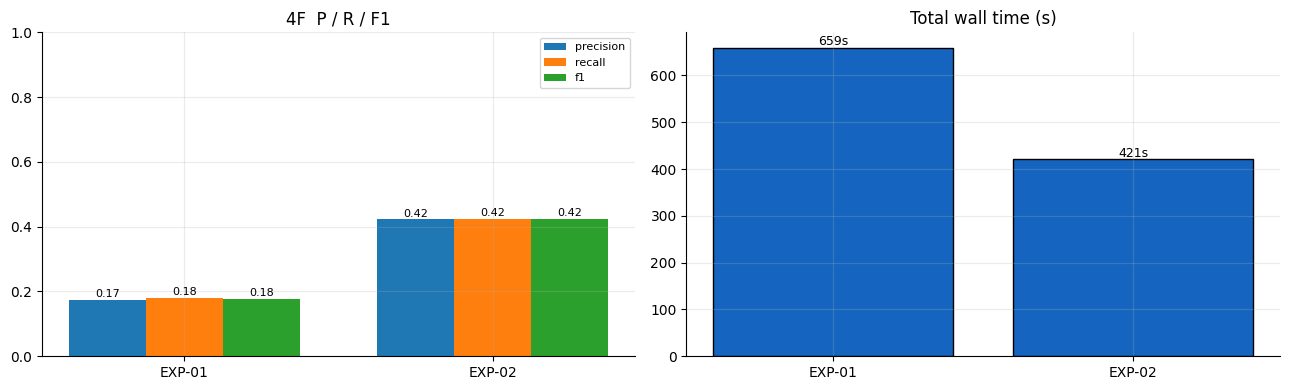

,label,full_tuple_precision,full_tuple_recall,full_tuple_f1,full4f_correct,full3f_f1,full3f_correct,nutrient_f1,quantity_acc,unit_acc,context_acc,matched_pairs,gt_tuples,predicted_tuples,total_wall_s,per_image_s,ocr_s,classifier_infer_s,association_s
experiment,,,,,,,,,,,,,,,,,,,
EXP-01,EasyOCR + ocr_corrector,0.1745,0.1801,0.1773,156,0.2364,208,0.6773,0.4547,0.5168,0.6141,596,866,894,659.26,11.507,650.99,0.08,2.64
EXP-02,PaddleOCR + paddleOCR_corrector_v2,0.4223,0.4238,0.4231,367,0.4415,383,0.7239,0.7691,0.8121,0.8726,628,866,869,420.79,7.378,416.14,0.08,3.31


In [10]:
compare_runs([run01, run02], title="Exp 1 — OCR engine")

In [11]:
# Experiment 2 — cascade parity across all three classifiers + pinned embedding op-point.
ablation_config["classifiers"]["embedding"].update({
    "confidence_threshold": 0.0,    # cascade keeps every token (same as rule_based)
    "nutrient_threshold":   0.59,   # = module default; pinned into the config snapshot
    "margin":               0.04,   # = module default; pinned into the config snapshot
})


In [12]:
run_e2c = run_pipeline_experiment(
    experiment_id="E2-C", label="PaddleOCR + GLiNER-biomed",
    ocr_engine="paddleocr", classifier_key="gliner", association_key="graph_v2",
)

[GLiNERClassifier] mode=gliner_only | Loading model: Ihor/gliner-biomed-bi-large-v1.0


Fetching 12 files: 100%|██████████| 12/12 [00:00<?, ?it/s]


[GLiNERClassifier] device=cuda
[GLiNERClassifier] Ready — single label: 'nutritional ingredient or vitamin or mineral'


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


  EXPERIMENT RESULTS : paddleocr_gliner_biomed
  EVALUATOR          : LLM-Assisted (qwen2.5:7b via Ollama)
  Images evaluated   : 57
  GT tuples          : 866
  Predicted tuples   : 751
  Matched pairs      : 552
─────────────────────────────────────────────────────────────────
  Nutrient Precision : 0.735
  Nutrient Recall    : 0.637
  Nutrient F1        : 0.683
─────────────────────────────────────────────────────────────────
  Quantity Match Acc : 76.3%
  Unit Match Acc     : 83.2%
  Context Match Acc  : 87.9%
─────────────────────────────────────────────────────────────────
  3-FIELD (no context) — nutrient + qty + unit
  ★ Full Tuple Precision : 48.1%
  ★ Full Tuple Recall    : 41.7%
  ★ Full Tuple F1        : 44.7%
─────────────────────────────────────────────────────────────────
  4-FIELD (with context) — primary thesis metric
  ★ Full Tuple Precision : 46.3%
  ★ Full Tuple Recall    : 40.2%
  ★ Full Tuple F1        : 43.0%
──────────────────────────────────────────────────────

...

,value
4F precision,0.4634
4F recall,0.4018
4F-F1,0.4304
4F hits,348.0000
3F precision,0.4807
3F recall,0.4169
3F-F1,0.4465
3F hits,361.0000
Nutrient P,0.7350
Nutrient R,0.6374


**Processing time (s)**

,seconds
total_wall_s,279.81
classifier_load_s,22.87
loop_s,256.52
eval_s,0.08
ocr_s,241.51
corrector_s,0.85
classifier_infer_s,12.69
association_s,1.46
per_image_s,4.50


**All evaluator metrics (full return)**

,value
experiment,paddleocr_gliner_biomed
timestamp,2026-06-20T21:22:23.262013
notes,ablation_redo
evaluator,LLM-Assisted (qwen2.5:7b)
schema,nutrient|quantity|unit|context
images_evaluated,57
gt_tuples,866
predicted_tuples,751
matched_pairs,552
nutrient_precision,0.735


In [13]:
run_e2b = run_pipeline_experiment(
    experiment_id="E2-B", label="PaddleOCR + embedding (BGE-M3)",
    ocr_engine="paddleocr", classifier_key="embedding", association_key="graph_v2",
)

[EmbeddingClassifier] mode=embedding_only | Loading model: BAAI/bge-m3
[EmbeddingClassifier] Ready — 125 prototypes across 5 categories
  EXPERIMENT RESULTS : paddleocr_embedding_bge_m3
  EVALUATOR          : LLM-Assisted (qwen2.5:7b via Ollama)
  Images evaluated   : 57
  GT tuples          : 866
  Predicted tuples   : 918
  Matched pairs      : 604
─────────────────────────────────────────────────────────────────
  Nutrient Precision : 0.658
  Nutrient Recall    : 0.697
  Nutrient F1        : 0.677
─────────────────────────────────────────────────────────────────
  Quantity Match Acc : 76.5%
  Unit Match Acc     : 83.1%
  Context Match Acc  : 86.4%
─────────────────────────────────────────────────────────────────
  3-FIELD (no context) — nutrient + qty + unit
  ★ Full Tuple Precision : 40.8%
  ★ Full Tuple Recall    : 43.3%
  ★ Full Tuple F1        : 42.0%
─────────────────────────────────────────────────────────────────
  4-FIELD (with context) — primary thesis metric
  ★ Full Tuple

### E2-B — PaddleOCR + embedding (BGE-M3)

- OCR `paddleocr` · classifier `embedding` (cpu) · association `graph_v2`
- images 57 · errors 0

**Hardware (per component)**

,component,hardware
0,OCR,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — paddleocr"
1,corrector,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — pure-Python"
2,classifier,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — embedding"
3,enricher,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel"
4,graph (V2 overlap),"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel"
5,associator (V2),"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — pure-Python"
6,evaluator,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — deterministic fa..."


...

,value
4F precision,0.3911
4F recall,0.4145
4F-F1,0.4025
4F hits,359.0000
3F precision,0.4085
3F recall,0.4330
3F-F1,0.4204
3F hits,375.0000
Nutrient P,0.6580
Nutrient R,0.6975


**Processing time (s)**

,seconds
total_wall_s,389.070
classifier_load_s,19.850
loop_s,369.050
eval_s,0.080
ocr_s,253.750
corrector_s,0.840
classifier_infer_s,112.990
association_s,1.470
per_image_s,6.475


**All evaluator metrics (full return)**

,value
experiment,paddleocr_embedding_bge_m3
timestamp,2026-06-20T21:32:03.037885
notes,ablation_redo
evaluator,LLM-Assisted (qwen2.5:7b)
schema,nutrient|quantity|unit|context
images_evaluated,57
gt_tuples,866
predicted_tuples,918
matched_pairs,604
nutrient_precision,0.658


In [14]:
from dataclasses import replace
run_e2a = replace(run02, experiment_id="E2-A", label="PaddleOCR + rule_based")
display_pipeline_run(run_e2a)

### E2-A — PaddleOCR + rule_based

- OCR `paddleocr` · classifier `rule_based` (cpu) · association `graph_v2`
- images 57 · errors 0

**Hardware (per component)**

,component,hardware
0,OCR,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — paddleocr"
1,corrector,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — pure-Python"
2,classifier,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — rule_based"
3,enricher,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel"
4,graph (V2 overlap),"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel"
5,associator (V2),"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — pure-Python"
6,evaluator,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — deterministic fa..."


**Headline metrics — fast evaluator**

,value
4F precision,0.4223
4F recall,0.4238
4F-F1,0.4231
4F hits,367.0000
3F precision,0.4407
3F recall,0.4423
3F-F1,0.4415
3F hits,383.0000
Nutrient P,0.7227
Nutrient R,0.7252


**Processing time (s)**

,seconds
total_wall_s,420.790
classifier_load_s,0.000
loop_s,420.520
eval_s,0.080
ocr_s,416.140
corrector_s,0.990
classifier_infer_s,0.080
association_s,3.310
per_image_s,7.378


**All evaluator metrics (full return)**

,value
experiment,paddleocr_paddleocr_corrector_v2
timestamp,2026-06-20T21:17:26.275602
notes,ablation_redo
evaluator,LLM-Assisted (qwen2.5:7b)
schema,nutrient|quantity|unit|context
images_evaluated,57
gt_tuples,866
predicted_tuples,869
matched_pairs,628
nutrient_precision,0.7227


### Experiment 2 — classifier

,label,full_tuple_precision,full_tuple_recall,full_tuple_f1,full4f_correct,full3f_f1,full3f_correct,nutrient_f1,quantity_acc,unit_acc,context_acc,matched_pairs,gt_tuples,predicted_tuples,total_wall_s,per_image_s,ocr_s,classifier_infer_s,association_s
experiment,,,,,,,,,,,,,,,,,,,
E2-A,PaddleOCR + rule_based,0.4223,0.4238,0.4231,367,0.4415,383,0.7239,0.7691,0.8121,0.8726,628,866,869,420.79,7.378,416.14,0.08,3.31
E2-B,PaddleOCR + embedding (BGE-M3),0.3911,0.4145,0.4025,359,0.4204,375,0.6771,0.7649,0.8311,0.8642,604,866,918,389.07,6.475,253.75,112.99,1.47
E2-C,PaddleOCR + GLiNER-biomed,0.4634,0.4018,0.4304,348,0.4465,361,0.6827,0.7627,0.8315,0.8786,552,866,751,279.81,4.500,241.51,12.69,1.46


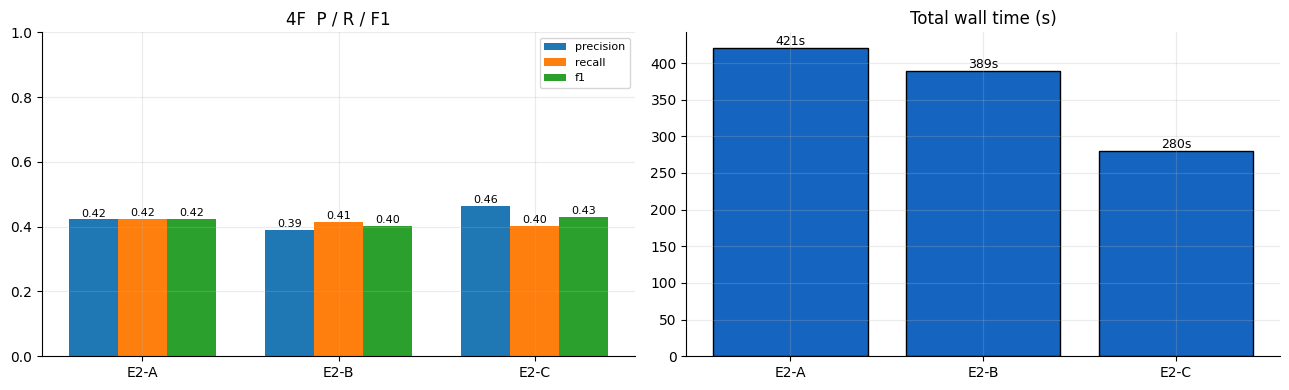

,label,full_tuple_precision,full_tuple_recall,full_tuple_f1,full4f_correct,full3f_f1,full3f_correct,nutrient_f1,quantity_acc,unit_acc,context_acc,matched_pairs,gt_tuples,predicted_tuples,total_wall_s,per_image_s,ocr_s,classifier_infer_s,association_s
experiment,,,,,,,,,,,,,,,,,,,
E2-A,PaddleOCR + rule_based,0.4223,0.4238,0.4231,367,0.4415,383,0.7239,0.7691,0.8121,0.8726,628,866,869,420.79,7.378,416.14,0.08,3.31
E2-B,PaddleOCR + embedding (BGE-M3),0.3911,0.4145,0.4025,359,0.4204,375,0.6771,0.7649,0.8311,0.8642,604,866,918,389.07,6.475,253.75,112.99,1.47
E2-C,PaddleOCR + GLiNER-biomed,0.4634,0.4018,0.4304,348,0.4465,361,0.6827,0.7627,0.8315,0.8786,552,866,751,279.81,4.500,241.51,12.69,1.46


In [15]:
compare_runs([run_e2a, run_e2b, run_e2c], title="Experiment 2 — classifier")

In [16]:
from dataclasses import replace
run_e3_gliner_g2 = replace(run_e2c, experiment_id="E3-GLiNER-G2", label="GLiNER + Graph V2")
run_e3_emb_g2    = replace(run_e2b, experiment_id="E3-EMB-G2",    label="Embedding + Graph V2")
display_pipeline_run(run_e3_gliner_g2); display_pipeline_run(run_e3_emb_g2)

### E3-GLiNER-G2 — GLiNER + Graph V2

- OCR `paddleocr` · classifier `gliner` (cuda) · association `graph_v2`
- images 57 · errors 0

**Hardware (per component)**

,component,hardware
0,OCR,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — paddleocr"
1,corrector,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — pure-Python"
2,classifier,GPU · NVIDIA GeForce RTX 5070 Laptop GPU (8.0 GB) — gliner
3,enricher,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel"
4,graph (V2 overlap),"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel"
5,associator (V2),"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — pure-Python"
6,evaluator,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — deterministic fa..."


**Headline metrics — fast evaluator**

...

,value
4F precision,0.3911
4F recall,0.4145
4F-F1,0.4025
4F hits,359.0000
3F precision,0.4085
3F recall,0.4330
3F-F1,0.4204
3F hits,375.0000
Nutrient P,0.6580
Nutrient R,0.6975


**Processing time (s)**

,seconds
total_wall_s,389.070
classifier_load_s,19.850
loop_s,369.050
eval_s,0.080
ocr_s,253.750
corrector_s,0.840
classifier_infer_s,112.990
association_s,1.470
per_image_s,6.475


**All evaluator metrics (full return)**

,value
experiment,paddleocr_embedding_bge_m3
timestamp,2026-06-20T21:32:03.037885
notes,ablation_redo
evaluator,LLM-Assisted (qwen2.5:7b)
schema,nutrient|quantity|unit|context
images_evaluated,57
gt_tuples,866
predicted_tuples,918
matched_pairs,604
nutrient_precision,0.658


In [17]:
run_e3_gliner_g1 = run_pipeline_experiment(
    experiment_id="E3-GLiNER-G1", label="GLiNER + Graph V1",
    ocr_engine="paddleocr", classifier_key="gliner", association_key="graph_v1",
)
run_e3_emb_g1 = run_pipeline_experiment(
    experiment_id="E3-EMB-G1", label="Embedding + Graph V1",
    ocr_engine="paddleocr", classifier_key="embedding", association_key="graph_v1",
)

[GLiNERClassifier] mode=gliner_only | Loading model: Ihor/gliner-biomed-bi-large-v1.0


Fetching 12 files: 100%|██████████| 12/12 [00:00<?, ?it/s]


[GLiNERClassifier] device=cuda
[GLiNERClassifier] Ready — single label: 'nutritional ingredient or vitamin or mineral'


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


  EXPERIMENT RESULTS : gliner_graph_v1
  EVALUATOR          : LLM-Assisted (qwen2.5:7b via Ollama)
  Images evaluated   : 57
  GT tuples          : 866
  Predicted tuples   : 775
  Matched pairs      : 543
─────────────────────────────────────────────────────────────────
  Nutrient Precision : 0.701
  Nutrient Recall    : 0.627
  Nutrient F1        : 0.662
─────────────────────────────────────────────────────────────────
  Quantity Match Acc : 69.2%
  Unit Match Acc     : 76.2%
  Context Match Acc  : 60.6%
─────────────────────────────────────────────────────────────────
  3-FIELD (no context) — nutrient + qty + unit
  ★ Full Tuple Precision : 39.2%
  ★ Full Tuple Recall    : 35.1%
  ★ Full Tuple F1        : 37.1%
─────────────────────────────────────────────────────────────────
  4-FIELD (with context) — primary thesis metric
  ★ Full Tuple Precision : 26.7%
  ★ Full Tuple Recall    : 23.9%
  ★ Full Tuple F1        : 25.2%
──────────────────────────────────────────────────────────────

...

,value
4F precision,0.2223
4F recall,0.2436
4F-F1,0.2325
4F hits,211.0000
3F precision,0.3277
3F recall,0.3591
3F-F1,0.3427
3F hits,311.0000
Nutrient P,0.6322
Nutrient R,0.6928


**Processing time (s)**

,seconds
total_wall_s,661.530
classifier_load_s,24.570
loop_s,636.520
eval_s,0.120
ocr_s,462.990
corrector_s,0.860
classifier_infer_s,172.340
association_s,0.320
per_image_s,11.167


**All evaluator metrics (full return)**

,value
experiment,embedding_graph_v1
timestamp,2026-06-20T21:53:33.372354
notes,ablation_redo
evaluator,LLM-Assisted (qwen2.5:7b)
schema,nutrient|quantity|unit|context
images_evaluated,57
gt_tuples,866
predicted_tuples,949
matched_pairs,600
nutrient_precision,0.6322


### Experiment 3 — GLiNER × association

,label,full_tuple_precision,full_tuple_recall,full_tuple_f1,full4f_correct,full3f_f1,full3f_correct,nutrient_f1,quantity_acc,unit_acc,context_acc,matched_pairs,gt_tuples,predicted_tuples,total_wall_s,per_image_s,ocr_s,classifier_infer_s,association_s
experiment,,,,,,,,,,,,,,,,,,,
E3-GLiNER-G1,GLiNER + Graph V1,0.2671,0.2390,0.2523,207,0.3705,304,0.6618,0.6924,0.7624,0.6059,543,866,775,593.39,9.665,538.64,10.86,0.35
E3-GLiNER-G2,GLiNER + Graph V2,0.4634,0.4018,0.4304,348,0.4465,361,0.6827,0.7627,0.8315,0.8786,552,866,751,279.81,4.500,241.51,12.69,1.46


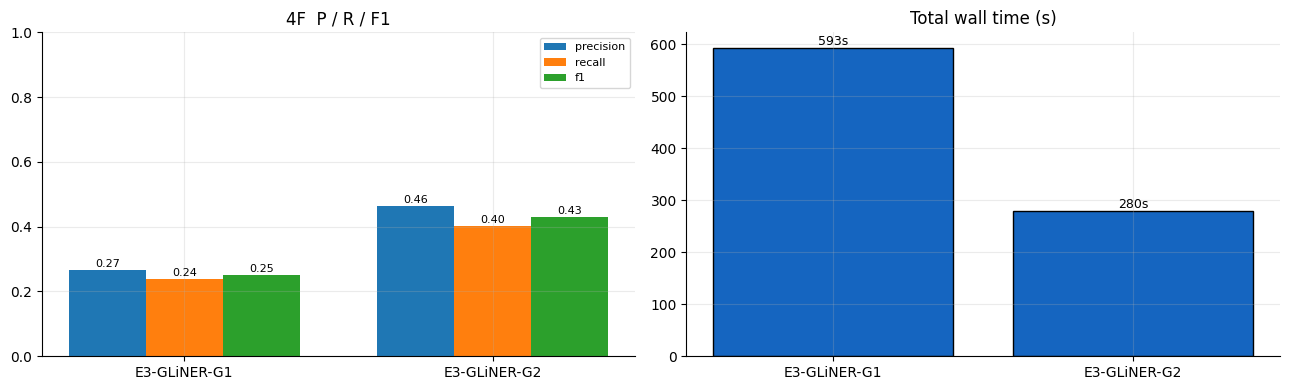

### Experiment 3 — Embedding × association

,label,full_tuple_precision,full_tuple_recall,full_tuple_f1,full4f_correct,full3f_f1,full3f_correct,nutrient_f1,quantity_acc,unit_acc,context_acc,matched_pairs,gt_tuples,predicted_tuples,total_wall_s,per_image_s,ocr_s,classifier_infer_s,association_s
experiment,,,,,,,,,,,,,,,,,,,
E3-EMB-G1,Embedding + Graph V1,0.2223,0.2436,0.2325,211,0.3427,311,0.6612,0.6950,0.7433,0.6150,600,866,949,661.53,11.167,462.99,172.34,0.32
E3-EMB-G2,Embedding + Graph V2,0.3911,0.4145,0.4025,359,0.4204,375,0.6771,0.7649,0.8311,0.8642,604,866,918,389.07,6.475,253.75,112.99,1.47


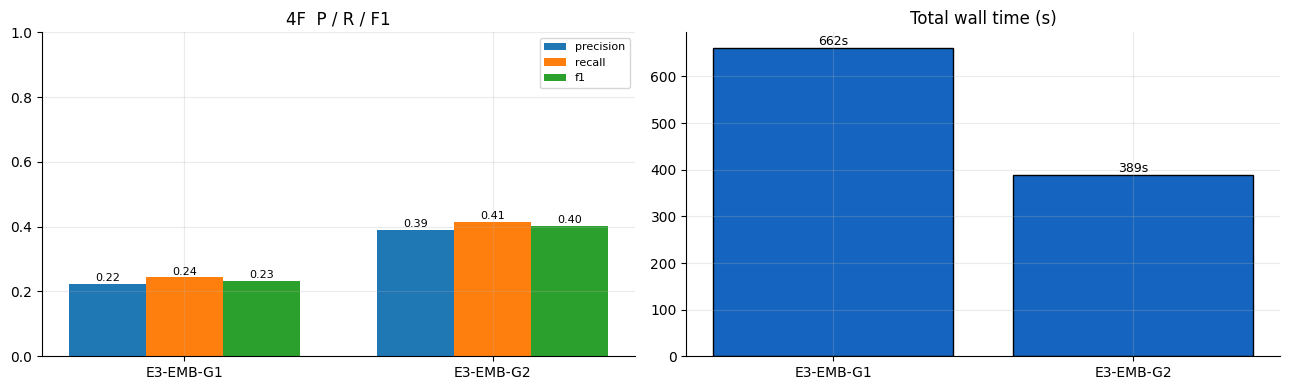

### Experiment 3 — full matrix

,label,full_tuple_precision,full_tuple_recall,full_tuple_f1,full4f_correct,full3f_f1,full3f_correct,nutrient_f1,quantity_acc,unit_acc,context_acc,matched_pairs,gt_tuples,predicted_tuples,total_wall_s,per_image_s,ocr_s,classifier_infer_s,association_s
experiment,,,,,,,,,,,,,,,,,,,
E3-GLiNER-G1,GLiNER + Graph V1,0.2671,0.2390,0.2523,207,0.3705,304,0.6618,0.6924,0.7624,0.6059,543,866,775,593.39,9.665,538.64,10.86,0.35
E3-GLiNER-G2,GLiNER + Graph V2,0.4634,0.4018,0.4304,348,0.4465,361,0.6827,0.7627,0.8315,0.8786,552,866,751,279.81,4.500,241.51,12.69,1.46
E3-EMB-G1,Embedding + Graph V1,0.2223,0.2436,0.2325,211,0.3427,311,0.6612,0.6950,0.7433,0.6150,600,866,949,661.53,11.167,462.99,172.34,0.32
E3-EMB-G2,Embedding + Graph V2,0.3911,0.4145,0.4025,359,0.4204,375,0.6771,0.7649,0.8311,0.8642,604,866,918,389.07,6.475,253.75,112.99,1.47


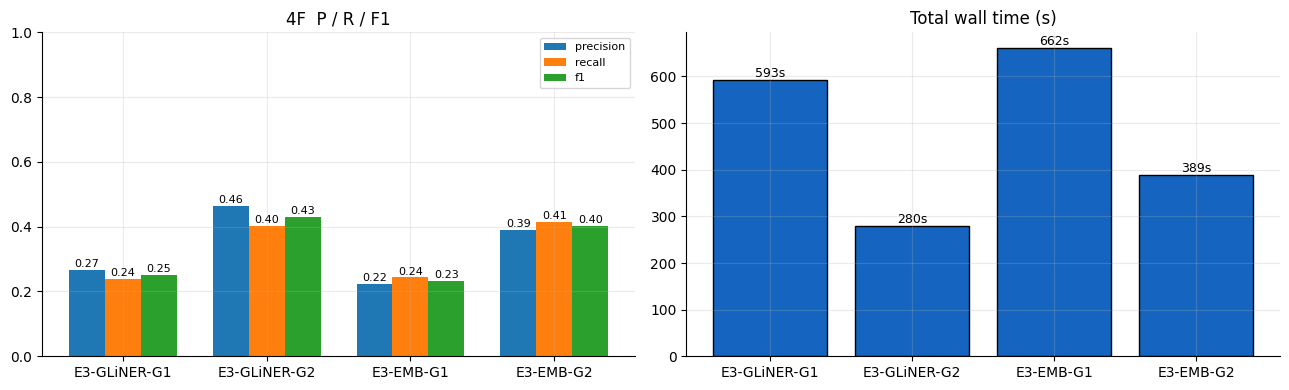

,label,full_tuple_precision,full_tuple_recall,full_tuple_f1,full4f_correct,full3f_f1,full3f_correct,nutrient_f1,quantity_acc,unit_acc,context_acc,matched_pairs,gt_tuples,predicted_tuples,total_wall_s,per_image_s,ocr_s,classifier_infer_s,association_s
experiment,,,,,,,,,,,,,,,,,,,
E3-GLiNER-G1,GLiNER + Graph V1,0.2671,0.2390,0.2523,207,0.3705,304,0.6618,0.6924,0.7624,0.6059,543,866,775,593.39,9.665,538.64,10.86,0.35
E3-GLiNER-G2,GLiNER + Graph V2,0.4634,0.4018,0.4304,348,0.4465,361,0.6827,0.7627,0.8315,0.8786,552,866,751,279.81,4.500,241.51,12.69,1.46
E3-EMB-G1,Embedding + Graph V1,0.2223,0.2436,0.2325,211,0.3427,311,0.6612,0.6950,0.7433,0.6150,600,866,949,661.53,11.167,462.99,172.34,0.32
E3-EMB-G2,Embedding + Graph V2,0.3911,0.4145,0.4025,359,0.4204,375,0.6771,0.7649,0.8311,0.8642,604,866,918,389.07,6.475,253.75,112.99,1.47


In [19]:
compare_runs([run_e3_gliner_g1, run_e3_gliner_g2],
             title="Experiment 3 — GLiNER × association")
compare_runs([run_e3_emb_g1, run_e3_emb_g2],
             title="Experiment 3 — Embedding × association")
compare_runs([run_e3_gliner_g1, run_e3_gliner_g2,
              run_e3_emb_g1, run_e3_emb_g2],
             title="Experiment 3 — full matrix")

In [2]:
# ════════════════════════════════════════════════════════════════════════
# SNIPPET 2b — Engine extension (run AFTER Snippet 2)
# Adds per-run graph_cfg + paragraph_fallback + prebuilt classifier_obj.
# Backward-compatible: with all three None, behaviour == Snippet 2, so the
# E1/E2/E3 calls are unchanged. Re-running Snippet 2 reverts these.
# ════════════════════════════════════════════════════════════════════════

def run_association(method: str, labeled_tokens, image_path, image_id,
                    vlm_cfg=None, graph_cfg=None, paragraph_fallback=None):
    """As Snippet 2, plus:
      graph_cfg          — explicit GraphConstructorV2 config (else the
                           ablation_config edge_mode trio).
      paragraph_fallback — override the global fallback flag for this run."""
    diagnostics = {}

    if method == "graph_v1":
        from src.graph.graph_constructor import GraphConstructor
        from src.matching.experiment_01_final_association import TupleAssociator
        graph  = GraphConstructor().build(labeled_tokens)
        tuples = TupleAssociator().extract(graph, image_id=image_id)
        diagnostics["nodes"] = len(graph.get("nodes", []))
        diagnostics["edges"] = len(graph.get("edges", []))
        return tuples, diagnostics

    if method == "graph_v2":
        from src.utils.token_enricher       import TokenEnricher
        from src.graph.graph_constructor_v2  import GraphConstructorV2
        from src.matching.association_v2     import TupleAssociatorV2
        from src.utils.paragraph_extractor   import extract_from_paragraph, should_use_paragraph_mode

        if graph_cfg is not None:
            gv2_cfg = dict(graph_cfg)
        else:
            em = ablation_config["graph_v2"]["edge_mode"]
            gv2_cfg = {"row_edge_mode": em, "col_edge_mode": em, "context_scope_mode": em}

        use_fallback = (ablation_config["graph_v2"]["paragraph_fallback"]
                        if paragraph_fallback is None else bool(paragraph_fallback))

        enriched = TokenEnricher().enrich(labeled_tokens)
        graph = GraphConstructorV2(config=gv2_cfg).build(enriched)
        tuples = TupleAssociatorV2().extract(graph, image_id=image_id)

        if use_fallback and should_use_paragraph_mode(labeled_tokens, len(tuples)):
            para = extract_from_paragraph(labeled_tokens, image_id)
            if len(para) > len(tuples):
                tuples = para
                diagnostics["paragraph_fallback"] = True

        diagnostics["row_edge_mode"] = gv2_cfg.get("row_edge_mode")
        diagnostics["nodes"] = graph.get("num_nodes", len(graph.get("nodes", [])))
        diagnostics["edges"] = graph.get("num_edges", len(graph.get("edges", [])))
        return tuples, diagnostics

    if method == "vlm":
        from src.utils.token_enricher    import TokenEnricher
        from src.matching.vlm_association import VLMAssociator
        enriched = TokenEnricher().enrich(labeled_tokens)
        cfg = dict(ablation_config["vlm"])
        if vlm_cfg:
            cfg.update(vlm_cfg)
        assoc  = VLMAssociator(cfg)
        tuples = assoc.extract(enriched_tokens=enriched, image_path=str(image_path),
                               image_id=image_id)
        diagnostics["vlm"] = getattr(assoc, "diagnostics", {})
        return tuples, diagnostics

    raise ValueError(f"Unknown association method: {method}")


def run_pipeline_on_image(image_path, *, ocr_fn, corrector_fn, classifier, association,
                          vlm_cfg=None, graph_cfg=None, paragraph_fallback=None):
    image_id = image_path.stem + image_path.suffix.lower()
    res = ImagePipelineResult(image_id=image_id, image_path=str(image_path))
    st = {}
    t_total = time.perf_counter()
    try:
        t = time.perf_counter()
        tokens = _ensure_cx_cy(ocr_fn(str(image_path)))
        st["ocr"] = time.perf_counter() - t
        res.n_tokens = len(tokens)

        t = time.perf_counter()
        corrected, _log = corrector_fn(tokens)
        corrected = _ensure_cx_cy(corrected)
        st["corrector"] = time.perf_counter() - t

        t = time.perf_counter()
        labeled = classifier.classify_all(corrected)
        st["classifier"] = time.perf_counter() - t
        res.n_labeled = dict(Counter(x.get("label", "UNKNOWN") for x in labeled))

        t = time.perf_counter()
        tuples, diag = run_association(method=association, labeled_tokens=labeled,
                                       image_path=image_path, image_id=image_id,
                                       vlm_cfg=vlm_cfg, graph_cfg=graph_cfg,
                                       paragraph_fallback=paragraph_fallback)
        st["association"] = time.perf_counter() - t
        for tup in tuples:
            tup["image_id"] = image_id
        res.tuples, res.diagnostics = tuples, diag

    except Exception as e:
        res.error = f"{type(e).__name__}: {e}"
        logger.error("Pipeline failed on %s: %s", image_id, res.error)
        if ablation_config["debug"]["strict_mode"]:
            raise

    res.stage_times = st
    res.duration_s  = round(time.perf_counter() - t_total, 3)
    return res


def run_pipeline_experiment(experiment_id: str, label: str,
                            ocr_engine: str, classifier_key: str, association_key: str,
                            classifier_device=None, classifier_obj=None,
                            graph_cfg=None, paragraph_fallback=None,
                            vlm_cfg=None, display_result: bool = True):
    """As Snippet 2, plus:
      classifier_obj     — a prebuilt ClassifierHandle to reuse (skips loading;
                           classifier_load_s = 0). When None, builds as before.
      graph_cfg          — per-run GraphConstructorV2 config (V2 path only).
      paragraph_fallback — per-run override of the global fallback flag."""
    t_wall  = time.perf_counter()
    out_dir = OUTPUT_DIR / f"{experiment_id}_{_slug(label)}"
    out_dir.mkdir(parents=True, exist_ok=True)
    logger.info("[%s] %s", experiment_id, label)

    ocr_fn       = build_ocr_engine(ocr_engine)
    corrector_fn = build_corrector(ocr_engine)

    if classifier_obj is not None:
        classifier        = classifier_obj
        classifier_load_s = 0.0
    else:
        t = time.perf_counter()
        classifier = build_classifier(classifier_key, device_override=classifier_device)
        classifier_load_s = time.perf_counter() - t
    resolved_dev = classifier.device

    images = list_images(RAW_DIR, limit=ablation_config["debug"]["limit_images"])
    logger.info("[%s] %d images · classifier=%s on %s (load %.1fs)%s",
                experiment_id, len(images), classifier.name, resolved_dev, classifier_load_s,
                f" · {graph_cfg}" if graph_cfg else "")

    stage_sum = defaultdict(float)
    all_preds, errors = [], []
    t_loop = time.perf_counter()
    for i, img in enumerate(images, 1):
        ir = run_pipeline_on_image(img, ocr_fn=ocr_fn, corrector_fn=corrector_fn,
                                   classifier=classifier, association=association_key,
                                   vlm_cfg=vlm_cfg, graph_cfg=graph_cfg,
                                   paragraph_fallback=paragraph_fallback)
        for k, v in ir.stage_times.items():
            stage_sum[k] += v
        if ir.error:
            errors.append({"image_id": ir.image_id, "error": ir.error})
        else:
            all_preds.extend(ir.tuples)
        if i % 10 == 0 or i == len(images):
            logger.info("[%s]   %d/%d processed (errors %d)",
                        experiment_id, i, len(images), len(errors))
    loop_s = time.perf_counter() - t_loop

    pred_cols = ["image_id", "nutrient", "quantity", "unit", "context"]
    pd.DataFrame([{k: t.get(k, "") for k in pred_cols} for t in all_preds]).to_csv(
        out_dir / "tuples.csv", index=False)
    if errors:
        pd.DataFrame(errors).to_csv(out_dir / "errors.csv", index=False)

    gt_rows = load_gt_from_csv(GT_CSV_PATH)
    t = time.perf_counter()
    try:
        eval_metrics = evaluate_fast_rule(
            all_preds, gt_rows, out_dir, _slug(label),
            use_llm=ablation_config["evaluation"]["use_llm_in_evaluator"],
            diagnostics={"experiment_id": experiment_id, "ocr": ocr_engine,
                         "classifier": classifier.name, "association": association_key,
                         "graph_cfg": graph_cfg, "paragraph_fallback": paragraph_fallback},
        )
    except Exception as e:
        logger.error("[%s] evaluator failed: %s", experiment_id, e)
        eval_metrics = {"evaluator_error": str(e)}
    eval_s = time.perf_counter() - t

    metrics = dict(eval_metrics)
    metrics.setdefault("n_images", len(images))
    metrics.setdefault("predicted_tuples", len(all_preds))
    metrics["n_errors"] = len(errors)
    if graph_cfg:
        metrics["row_edge_mode"]     = graph_cfg.get("row_edge_mode")
        metrics["paragraph_fallback"] = (bool(paragraph_fallback)
                                         if paragraph_fallback is not None
                                         else ablation_config["graph_v2"]["paragraph_fallback"])

    timing = {
        "total_wall_s":       round(time.perf_counter() - t_wall, 2),
        "classifier_load_s":  round(classifier_load_s, 2),
        "loop_s":             round(loop_s, 2),
        "eval_s":             round(eval_s, 2),
        "ocr_s":              round(stage_sum.get("ocr", 0.0), 2),
        "corrector_s":        round(stage_sum.get("corrector", 0.0), 2),
        "classifier_infer_s": round(stage_sum.get("classifier", 0.0), 2),
        "association_s":      round(stage_sum.get("association", 0.0), 2),
        "per_image_s":        round(loop_s / max(len(images), 1), 3),
    }
    hardware = build_hardware_manifest(ocr_engine, classifier.name, resolved_dev, association_key)

    with open(out_dir / "quantitative_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, default=str)
    with open(out_dir / "timing.json", "w", encoding="utf-8") as f:
        json.dump(timing, f, indent=2, default=str)
    with open(out_dir / "hardware_manifest.json", "w", encoding="utf-8") as f:
        json.dump(hardware, f, indent=2, default=str)

    run = PipelineRun(experiment_id=experiment_id, label=label, ocr_engine=ocr_engine,
                      classifier_key=classifier.name, association_key=association_key,
                      classifier_device=resolved_dev, out_dir=out_dir,
                      metrics=metrics, timing=timing, hardware=hardware,
                      n_images=len(images), n_errors=len(errors),
                      predictions=all_preds, errors=errors)
    if display_result:
        display_pipeline_run(run)
    return run


print("[Snippet 2b] engine extended — graph_cfg / paragraph_fallback / classifier_obj live.")

[Snippet 2b] engine extended — graph_cfg / paragraph_fallback / classifier_obj live.


In [3]:
from dataclasses import replace

gliner_clf = build_classifier("gliner")      # GPU, load once
emb_clf    = build_classifier("embedding")   # CPU, load once

NEW_CONFIGS = [
    ("cy",       {"row_edge_mode": "cy",           "col_edge_mode": "cx", "context_scope_mode": "cy"}),
    ("rolerank", {"row_edge_mode": "role_rank",    "col_edge_mode": "cx", "context_scope_mode": "cy"}),
    ("merged",   {"row_edge_mode": "role_rank_cy", "col_edge_mode": "cx", "context_scope_mode": "cy"}),
]

runs_e5_gliner = {}
for tag, cfg in NEW_CONFIGS:
    runs_e5_gliner[tag] = run_pipeline_experiment(
        experiment_id=f"E5-GLiNER-{tag}", label=f"GLiNER · {cfg['row_edge_mode']}",
        ocr_engine="paddleocr", classifier_key="gliner", association_key="graph_v2",
        classifier_obj=gliner_clf, graph_cfg=cfg, paragraph_fallback=True,
    )
runs_e5_gliner["overlap"] = replace(run_e2c, experiment_id="E5-GLiNER-overlap",
    label="GLiNER · overlap", metrics={**run_e2c.metrics, "row_edge_mode": "overlap"})
display_pipeline_run(runs_e5_gliner["overlap"])

runs_e5_emb = {}
for tag, cfg in NEW_CONFIGS:
    runs_e5_emb[tag] = run_pipeline_experiment(
        experiment_id=f"E5-EMB-{tag}", label=f"Embedding · {cfg['row_edge_mode']}",
        ocr_engine="paddleocr", classifier_key="embedding", association_key="graph_v2",
        classifier_obj=emb_clf, graph_cfg=cfg, paragraph_fallback=True,
    )
runs_e5_emb["overlap"] = replace(run_e2b, experiment_id="E5-EMB-overlap",
    label="Embedding · overlap", metrics={**run_e2b.metrics, "row_edge_mode": "overlap"})
display_pipeline_run(runs_e5_emb["overlap"])

# If run_e2c/run_e2b aren't in memory, run overlap fresh instead of the two replace() lines:
# runs_e5_gliner["overlap"] = run_pipeline_experiment(
#     experiment_id="E5-GLiNER-overlap", label="GLiNER · overlap",
#     ocr_engine="paddleocr", classifier_key="gliner", association_key="graph_v2",
#     classifier_obj=gliner_clf,
#     graph_cfg={"row_edge_mode":"overlap","col_edge_mode":"overlap","context_scope_mode":"overlap"},
#     paragraph_fallback=True)   # (same shape for EMB with emb_clf / run_e2b)

NameError: name 'build_classifier' is not defined

In [12]:
# ════════════════════════════════════════════════════════════════════════
# E4 — End-to-end VLM baseline (your EXP-12) — INDEPENDENT, EXACT extraction
# Your original EXP-12 prompts + image encoder + parser + call loop, VERBATIM,
# wrapped in the current framework (C15 post-pass, evaluator, PipelineRun,
# hardware manifest). Runs in a FRESH kernel with no other cells executed.
# Gemma must be LOADED in LM Studio. Slow (one sequential call per image).
# ════════════════════════════════════════════════════════════════════════

import io, os, sys, re as _re, json, time, base64, logging, platform
import urllib.request, urllib.error
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Any, Tuple

import pandas as pd
from PIL import Image, ImageOps
from IPython.display import display, Markdown

# Logger — reuse Snippet 1's if present, else create.
try:
    logger
except NameError:
    if not logging.getLogger().handlers:
        logging.basicConfig(level=logging.INFO,
                            format="%(asctime)s [%(levelname)s] %(name)s :: %(message)s",
                            datefmt="%H:%M:%S")
    logger = logging.getLogger("ablation")


# ── Project root (data/ + src/ markers); reuse PROJECT_ROOT if present ──
def _e4_find_root(start, markers=("data", "src"), max_up=8) -> Path:
    cur = Path(start).resolve()
    for _ in range(max_up):
        if all((cur / m).is_dir() for m in markers):
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return Path(start).resolve()

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = _e4_find_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ── Config — reuse ablation_config if present, else built-in defaults ───
_E4_DEFAULTS = {
    "vlm": {
        "openai_base_url": "http://127.0.0.1:1234/v1/chat/completions",
        "openai_model":    "google/gemma-3-4b",
        "temperature":     0.1,
        "max_tokens":      4096,
        "timeout_s":       600,
    },
    "raw_dir":              "data/raw",
    "ground_truth_csv":     "data/annotations/test_set_normalized.csv",
    "output_dir":           "results/ablation_redo",
    "image_extensions":     {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"},
    "use_llm_in_evaluator": False,
    "llm_evaluator_model":  "qwen2.5:7b",
    "limit_images":         None,
}
try:
    _E4_CFG = {
        "vlm":                  dict(ablation_config["vlm"]),
        "raw_dir":              ablation_config["data"]["raw_dir"],
        "ground_truth_csv":     ablation_config["data"]["ground_truth_csv"],
        "output_dir":           ablation_config["output_dir"],
        "image_extensions":     ablation_config["data"]["image_extensions"],
        "use_llm_in_evaluator": ablation_config["evaluation"]["use_llm_in_evaluator"],
        "llm_evaluator_model":  ablation_config["evaluation"]["llm_evaluator_model"],
        "limit_images":         ablation_config["debug"]["limit_images"],
    }
    logger.info("[E4] using existing ablation_config.")
except NameError:
    _E4_CFG = dict(_E4_DEFAULTS)
    logger.info("[E4] ablation_config not found — using built-in defaults.")

_E4_RAW = PROJECT_ROOT / _E4_CFG["raw_dir"]
_E4_GT  = PROJECT_ROOT / _E4_CFG["ground_truth_csv"]
_E4_OUT = PROJECT_ROOT / _E4_CFG["output_dir"]


# ── Hardware labels (reuse Snippet 1's if present, else probe) ──────────
def _e4_probe_gpu() -> str:
    try:
        import torch
        if torch.cuda.is_available():
            name = torch.cuda.get_device_name(0)
            vram = round(torch.cuda.get_device_properties(0).total_memory / (1024 ** 3), 1)
            return f"GPU · {name} ({vram} GB)"
    except Exception:
        pass
    return "GPU · (none detected)"

try:
    _E4_CPU = CPU_LABEL
    _E4_GPU = GPU_LABEL
except NameError:
    _E4_CPU = f"CPU · {platform.processor() or platform.machine() or 'unknown CPU'}"
    _E4_GPU = _e4_probe_gpu()

logger.info("[E4] root=%s | raw exists=%s | gt exists=%s | %s | %s",
            PROJECT_ROOT, _E4_RAW.exists(), _E4_GT.exists(), _E4_CPU, _E4_GPU)


# ════════════════════════════════════════════════════════════════════════
# ORIGINAL EXP-12 HELPERS — VERBATIM (prompts · encoder · parser · call · loop)
# ════════════════════════════════════════════════════════════════════════

E2E_VLM_SYSTEM_PROMPT = (
    "You are an expert at extracting structured nutrient information from "
    "supplement and food label images. Output ONLY a valid JSON array. "
    "No prose, no markdown fences, no commentary."
)

E2E_VLM_USER_PROMPT = """Look at this supplement / food label image and extract every nutrient row.

For each nutrient on the label, output ONE entry with:
  - nutrient: canonical English name (e.g. "Vitamin C", "Magnesium", "Calcium", "Folic Acid", "Iron")
  - quantity: numeric value as a string (e.g. "80", "2.5", "1.5")
  - unit: standard unit (mg, g, µg, kJ, kcal, IU, ml, l)
  - context: EXACTLY ONE of: per_100g, per_100ml, per_serving, per_daily_dose, etc.

Rules:
- One entry per (nutrient, context) combination. If shown per_100g AND per_serving, emit two entries.
- Skip sub-nutrients labelled "davon" / "of which" unless their values are clearly distinct.
- Skip NRV%, %DV, %RDA, %RI.
- Skip ingredient lists, marketing copy, addresses.
- Convert German to canonical English ("Zucker"->"Sugars", "Eisen"->"Iron", "Kalium"->"Potassium", "Eiweiss"->"Protein").
- Use " µg" for micrograms.

DECIMAL SEPARATOR -- CRITICAL:
German/EU labels use "," (comma) as decimal separator. Convert ALL commas in quantity to "." (period).
  "1,5"   -> "1.5"
  "0,02"  -> "0.02"
  "12,5"  -> "12.5"
Never emit a comma inside a quantity string.

Return ONLY the JSON array. Example:
[
  {"nutrient": "Vitamin C", "quantity": "80",  "unit": "mg", "context": "per_serving"},
  {"nutrient": "Magnesium",  "quantity": "1.5", "unit": "mg", "context": "per_daily_dose"}
]
"""


def _image_to_base64_jpeg(image_path, max_side=896, quality=95):
    with Image.open(image_path) as im:
        im = ImageOps.exif_transpose(im).convert("RGB")
        if max(im.size) > max_side:
            im.thumbnail((max_side, max_side), Image.Resampling.LANCZOS)
        buf = io.BytesIO()
        im.save(buf, format="JPEG", quality=quality, optimize=True)
        return base64.b64encode(buf.getvalue()).decode("ascii")


def _strip_vlm_response(text):
    if not text:
        return ""
    text = _re.sub(r"<think>.*?</think>", "", text, flags=_re.DOTALL | _re.IGNORECASE)
    fence = _re.search(r"```(?:json)?\s*(.+?)```", text, _re.DOTALL)
    if fence:
        text = fence.group(1)
    text = _re.sub(r",(\s*[}\]])", r"\1", text)
    return text.strip()


def _normalize_quantity_string(raw):
    s = str(raw if raw is not None else "").strip()
    if not s:
        return ""
    if "," in s and s.count(".") >= 1 and s.rfind(",") > s.rfind("."):
        s = s.replace(".", "")
    s = s.replace(",", ".")
    return s


def _parse_e2e_vlm_response(text, image_id):
    stripped = _strip_vlm_response(text)
    if not stripped:
        return [], "empty response"
    try:
        data = json.loads(stripped)
    except json.JSONDecodeError as e:
        arr = _re.search(r"\[\s*\{.*?\}\s*\]", stripped, _re.DOTALL)
        if not arr:
            return [], f"JSON parse failed: {e}"
        try:
            data = json.loads(arr.group(0))
        except Exception as e2:
            return [], f"JSON parse failed (relaxed): {e2}"
    if not isinstance(data, list):
        return [], f"expected JSON array, got {type(data).__name__}"
    tuples = []
    for raw in data:
        if not isinstance(raw, dict):
            continue
        row = {k.lower(): v for k, v in raw.items()}
        tuples.append({
            "image_id": image_id,
            "nutrient": str(row.get("nutrient", "") or "").strip(),
            "quantity": _normalize_quantity_string(row.get("quantity")),
            "unit":     str(row.get("unit",     "") or "").strip(),
            "context":  str(row.get("context",  "") or "").strip(),
        })
    return tuples, None


def _call_lm_studio_vision(image_path, base_url, model,
                           temperature=0.1, max_tokens=4096, timeout_s=600):
    b64 = _image_to_base64_jpeg(image_path)
    body = {
        "model":       model,
        "temperature": temperature,
        "max_tokens":  max_tokens,
        "messages": [
            {"role": "system", "content": E2E_VLM_SYSTEM_PROMPT},
            {"role": "user", "content": [
                {"type": "text",      "text": E2E_VLM_USER_PROMPT},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
            ]},
        ],
    }
    req = urllib.request.Request(
        base_url,
        data=json.dumps(body).encode("utf-8"),
        headers={"Content-Type": "application/json"},
    )
    t0 = time.perf_counter()
    with urllib.request.urlopen(req, timeout=timeout_s) as r:
        resp = json.loads(r.read().decode("utf-8"))
    elapsed = time.perf_counter() - t0
    text = resp.get("choices", [{}])[0].get("message", {}).get("content", "") or ""
    return text, elapsed


def run_exp12_end_to_end_vlm(images, out_dir, base_url, model,
                              temperature=0.1, max_tokens=4096,
                              timeout_s=600, save_responses=False):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    all_tuples, errors, times, raw_responses = [], [], [], []

    for i, img_path in enumerate(images, 1):
        image_id = img_path.stem + img_path.suffix.lower()
        t0 = time.perf_counter()
        try:
            text, vlm_elapsed = _call_lm_studio_vision(
                image_path=img_path, base_url=base_url, model=model,
                temperature=temperature, max_tokens=max_tokens, timeout_s=timeout_s,
            )
            tuples, parse_err = _parse_e2e_vlm_response(text, image_id)
            if parse_err:
                errors.append({"image_id": image_id, "stage": "parse", "error": parse_err})
            else:
                all_tuples.extend(tuples)
            if save_responses:
                raw_responses.append({"image_id": image_id, "response": text, "n_tuples": len(tuples)})
            total_s = time.perf_counter() - t0
            times.append({
                "image_id":                image_id,
                "status":                  "parse_error" if parse_err else "ok",
                "predicted_tuples":        len(tuples),
                "vlm_time_s":              round(vlm_elapsed, 3),
                "total_processing_time_s": round(total_s,     3),
                "error":                   parse_err or "",
            })
            logger.info("[EXP-12] %3d/%3d %-16s -> %d tuples  (%.1fs)",
                        i, len(images), image_id, len(tuples), vlm_elapsed)
        except Exception as e:
            total_s = time.perf_counter() - t0
            err_msg = f"{type(e).__name__}: {e}"
            errors.append({"image_id": image_id, "stage": "api", "error": err_msg})
            times.append({
                "image_id":                image_id,
                "status":                  "error",
                "predicted_tuples":        0,
                "vlm_time_s":              0.0,
                "total_processing_time_s": round(total_s, 3),
                "error":                   err_msg,
            })
            logger.error("[EXP-12] %3d/%3d %s FAILED: %s", i, len(images), image_id, err_msg)

    pred_cols = ["image_id", "nutrient", "quantity", "unit", "context"]
    pd.DataFrame([{k: t.get(k, "") for k in pred_cols} for t in all_tuples]) \
        .to_csv(out_dir / "tuples.csv", index=False)
    pd.DataFrame(times).to_csv(out_dir / "processing_times.csv", index=False)
    if errors:
        pd.DataFrame(errors).to_csv(out_dir / "errors.csv", index=False)
    if save_responses and raw_responses:
        with open(out_dir / "raw_responses.json", "w", encoding="utf-8") as f:
            json.dump(raw_responses, f, indent=2, ensure_ascii=False)

    return {
        "n_images":     len(images),
        "n_tuples":     len(all_tuples),
        "n_errors":     len(errors),
        "total_time_s": sum(t["total_processing_time_s"] for t in times),
        "out_dir":      str(out_dir),
        "all_tuples":   all_tuples,
    }


# ════════════════════════════════════════════════════════════════════════
# E4 WRAPPER — C15 post-pass · evaluator · PipelineRun · hardware manifest
# ════════════════════════════════════════════════════════════════════════

def _e4_apply_c15(predictions: list):
    """C15 nutrient-name normalisation — parity with the structured pipeline."""
    try:
        from src.utils.paddleOCR_corrector_v2 import apply_c15_normalise_names
    except ImportError:
        from paddleOCR_corrector_v2 import apply_c15_normalise_names   # flat-layout fallback
    if not predictions:
        return list(predictions), 0
    wrapped = [{"token": p.get("nutrient", "")} for p in predictions]
    normed  = apply_c15_normalise_names(wrapped)
    out, n_changed = [], 0
    for orig, nm in zip(predictions, normed):
        new = dict(orig)
        nn  = nm.get("token", orig.get("nutrient", ""))
        if nn != orig.get("nutrient", ""):
            n_changed += 1
        new["nutrient"] = nn
        out.append(new)
    return out, n_changed


def _e4_list_images(raw_dir: Path, limit: Optional[int] = None) -> List[Path]:
    exts = _E4_CFG["image_extensions"]
    files = [f for f in Path(raw_dir).iterdir() if f.suffix.lower() in exts]
    files.sort(key=lambda f: (int(f.stem) if f.stem.isdigit() else float("inf"), f.name))
    return files[:limit] if limit else files


def _e4_load_gt(csv_path: Path) -> List[Dict[str, str]]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"GT CSV not found: {csv_path}")
    df = pd.read_csv(csv_path, dtype=str, keep_default_na=False)
    rows = []
    for _, r in df.iterrows():
        raw_id = str(r.get("image_id", "") or "").strip()
        if not raw_id:
            continue
        image_id     = Path(raw_id).stem + Path(raw_id).suffix.lower()
        context      = str(r.get("context", "") or "").strip()
        serving_size = str(r.get("serving_size", "") or "").strip()
        context_full = f"{context} ({serving_size})" if serving_size else context
        rows.append({"image_id": image_id,
                     "nutrient": str(r.get("nutrient", "") or "").strip(),
                     "quantity": str(r.get("quantity", "") or "").strip(),
                     "unit":     str(r.get("unit", "") or "").strip(),
                     "context":  context_full})
    return rows


def _e4_slug(s: str) -> str:
    return _re.sub(r"[^a-zA-Z0-9]+", "_", s).strip("_").lower()


def _e4_scalar(d: dict) -> dict:
    return {k: v for k, v in d.items()
            if isinstance(v, (int, float, str, bool)) or v is None}


# Result type — reuse Snippet 2's PipelineRun if present, else define.
try:
    PipelineRun
except NameError:
    @dataclass
    class PipelineRun:
        experiment_id:     str
        label:             str
        ocr_engine:        str
        classifier_key:    str
        association_key:   str
        classifier_device: str
        out_dir:           Path
        metrics:           Dict[str, Any]
        timing:            Dict[str, float]
        hardware:          Dict[str, str]
        n_images:          int
        n_errors:          int
        predictions:       List[Dict] = field(default_factory=list)
        errors:            List[Dict] = field(default_factory=list)


def run_e4_experiment(experiment_id: str = "E4",
                      label: str = "VLM end-to-end (Gemma 3 4B)",
                      vlm_cfg: dict = None, apply_c15: bool = True,
                      save_responses: bool = False, display_result: bool = True):
    cfg = dict(_E4_CFG["vlm"])
    if vlm_cfg:
        cfg.update(vlm_cfg)
    out_dir = _E4_OUT / f"{experiment_id}_{_e4_slug(label)}"
    out_dir.mkdir(parents=True, exist_ok=True)
    logger.info("[%s] %s — %s @ %s", experiment_id, label, cfg["openai_model"], cfg["openai_base_url"])

    images = _e4_list_images(_E4_RAW, limit=_E4_CFG["limit_images"])

    # ── EXACT EXP-12 extraction loop (writes tuples.csv [raw] + processing_times.csv) ──
    run = run_exp12_end_to_end_vlm(
        images=images, out_dir=out_dir,
        base_url=cfg["openai_base_url"], model=cfg["openai_model"],
        temperature=cfg.get("temperature", 0.1), max_tokens=cfg.get("max_tokens", 4096),
        timeout_s=cfg.get("timeout_s", 600), save_responses=save_responses,
    )

    pred_cols = ["image_id", "nutrient", "quantity", "unit", "context"]
    raw = run["all_tuples"]
    pd.DataFrame([{k: t.get(k, "") for k in pred_cols} for t in raw]).to_csv(
        out_dir / "tuples_raw.csv", index=False)               # pre-C15 snapshot

    preds, n_c15 = raw, 0
    if apply_c15:
        preds, n_c15 = _e4_apply_c15(raw)
    pd.DataFrame([{k: t.get(k, "") for k in pred_cols} for t in preds]).to_csv(
        out_dir / "tuples.csv", index=False)                   # overwrite with C15-normalised

    gt_rows = _e4_load_gt(_E4_GT)
    try:
        from src.evaluation.llm_evaluator import LLMTupleEvaluator
        evaluator = LLMTupleEvaluator(gt_rows=gt_rows,
                                      use_llm=_E4_CFG["use_llm_in_evaluator"],
                                      model=_E4_CFG["llm_evaluator_model"])
        eval_metrics = evaluator.run(
            predictions=preds, experiment=_e4_slug(label), out_dir=out_dir,
            notes="ablation_redo_e4",
            diagnostics={"experiment_id": experiment_id, "end_to_end_vlm": True,
                         "model": cfg["openai_model"], "n_api_errors": run["n_errors"],
                         "c15_applied": apply_c15, "c15_normalised": n_c15,
                         "total_time_s": run["total_time_s"]})
    except Exception as e:
        logger.error("[%s] evaluator failed: %s", experiment_id, e)
        eval_metrics = {"evaluator_error": str(e)}

    metrics = dict(eval_metrics)
    metrics.setdefault("n_images", run["n_images"])
    metrics.setdefault("predicted_tuples", len(preds))
    metrics["n_errors"]       = run["n_errors"]
    metrics["c15_normalised"] = n_c15
    n_pred = int(metrics.get("predicted_tuples", len(preds)) or 0)
    n_gt   = int(metrics.get("gt_tuples", len(gt_rows)) or 0)
    tp     = int(metrics.get("full4f_correct", 0) or 0)
    metrics.setdefault("tp", tp)
    metrics.setdefault("fp", max(0, n_pred - tp))
    metrics.setdefault("fn", max(0, n_gt - tp))

    n_img = max(run["n_images"], 1)
    timing = {"total_wall_s": round(run["total_time_s"], 2),
              "per_image_s":  round(run["total_time_s"] / n_img, 2),
              "vlm_calls":    run["n_images"]}
    hardware = {"VLM (end-to-end)": f"{_E4_GPU} — LM Studio · {cfg['openai_model']} (full GPU offload)",
                "evaluator":        f"{_E4_CPU} — deterministic fast-rule"}

    with open(out_dir / "quantitative_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, default=str)
    with open(out_dir / "timing.json", "w", encoding="utf-8") as f:
        json.dump(timing, f, indent=2, default=str)
    with open(out_dir / "hardware_manifest.json", "w", encoding="utf-8") as f:
        json.dump(hardware, f, indent=2, default=str)

    prun = PipelineRun(experiment_id=experiment_id, label=label, ocr_engine="none",
                       classifier_key="none", association_key="vlm_e2e",
                       classifier_device="n/a", out_dir=out_dir, metrics=metrics,
                       timing=timing, hardware=hardware, n_images=run["n_images"],
                       n_errors=run["n_errors"], predictions=preds, errors=[])

    if display_result:
        display(Markdown(f"### {experiment_id} — {label}"))
        display(Markdown(
            f"- Model `{cfg['openai_model']}` @ `{cfg['openai_base_url']}`\n"
            f"- Images {run['n_images']} · errors {run['n_errors']} · "
            f"C15 normalised {n_c15}/{len(preds)}\n"
            f"- Predicted {n_pred} · GT {n_gt}\n"
            f"- **4F-F1 {float(metrics.get('full_tuple_f1') or 0):.4f}** "
            f"(P {float(metrics.get('full_tuple_precision') or 0):.4f}, "
            f"R {float(metrics.get('full_tuple_recall') or 0):.4f}) · "
            f"4F hits {metrics.get('full4f_correct')} · 3F hits {metrics.get('full3f_correct')}\n"
            f"- Total {run['total_time_s'] / 60:.1f} min ({timing['per_image_s']:.1f} s/image)"))
        display(Markdown("**Hardware (per component)**"))
        display(pd.DataFrame(list(hardware.items()), columns=["component", "hardware"]))
        display(Markdown("**All evaluator metrics**"))
        display(pd.DataFrame([_e4_scalar(metrics)]).T.rename(columns={0: "value"}))

    return prun


print("[E4] ready — exact EXP-12 prompt + parser. Call run_e4_experiment() with Gemma loaded.")

23:00:49 [INFO] ablation :: [E4] using existing ablation_config.
23:00:49 [INFO] ablation :: [E4] root=C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association | raw exists=True | gt exists=True | CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel | GPU · NVIDIA GeForce RTX 5070 Laptop GPU (8.0 GB)


[E4] ready — exact EXP-12 prompt + parser. Call run_e4_experiment() with Gemma loaded.


In [13]:
run_e4 = run_e4_experiment()          # ~57 sequential Gemma calls — slow

23:00:57 [INFO] ablation :: [E4] VLM end-to-end (Gemma 3 4B) — google/gemma-3-4b @ http://127.0.0.1:1234/v1/chat/completions
23:01:04 [INFO] ablation :: [EXP-12]   1/ 57 1.png            -> 5 tuples  (6.9s)
23:01:11 [INFO] ablation :: [EXP-12]   2/ 57 2.png            -> 10 tuples  (6.6s)
23:01:15 [INFO] ablation :: [EXP-12]   3/ 57 4.png            -> 5 tuples  (4.1s)
23:01:20 [INFO] ablation :: [EXP-12]   4/ 57 6.png            -> 6 tuples  (4.2s)
23:01:30 [INFO] ablation :: [EXP-12]   5/ 57 8.png            -> 16 tuples  (10.1s)
23:01:34 [INFO] ablation :: [EXP-12]   6/ 57 9.jpeg           -> 4 tuples  (3.4s)
23:01:42 [INFO] ablation :: [EXP-12]   7/ 57 12.png           -> 14 tuples  (8.4s)
23:01:50 [INFO] ablation :: [EXP-12]   8/ 57 15.png           -> 12 tuples  (7.6s)
23:01:54 [INFO] ablation :: [EXP-12]   9/ 57 17.png           -> 4 tuples  (3.7s)
23:02:14 [INFO] ablation :: [EXP-12]  10/ 57 20.png           -> 32 tuples  (20.2s)
23:02:19 [INFO] ablation :: [EXP-12]  11/ 57 26.

  EXPERIMENT RESULTS : vlm_end_to_end_gemma_3_4b
  EVALUATOR          : LLM-Assisted (qwen2.5:7b via Ollama)
  Images evaluated   : 57
  GT tuples          : 866
  Predicted tuples   : 641
  Matched pairs      : 588
─────────────────────────────────────────────────────────────────
  Nutrient Precision : 0.917
  Nutrient Recall    : 0.679
  Nutrient F1        : 0.780
─────────────────────────────────────────────────────────────────
  Quantity Match Acc : 75.3%
  Unit Match Acc     : 92.5%
  Context Match Acc  : 56.3%
─────────────────────────────────────────────────────────────────
  3-FIELD (no context) — nutrient + qty + unit
  ★ Full Tuple Precision : 66.8%
  ★ Full Tuple Recall    : 49.4%
  ★ Full Tuple F1        : 56.8%
─────────────────────────────────────────────────────────────────
  4-FIELD (with context) — primary thesis metric
  ★ Full Tuple Precision : 42.3%
  ★ Full Tuple Recall    : 31.3%
  ★ Full Tuple F1        : 36.0%
────────────────────────────────────────────────────

### E4 — VLM end-to-end (Gemma 3 4B)

- Model `google/gemma-3-4b` @ `http://127.0.0.1:1234/v1/chat/completions`
- Images 57 · errors 0 · C15 normalised 163/641
- Predicted 641 · GT 866
- **4F-F1 0.3597** (P 0.4228, R 0.3129) · 4F hits 271 · 3F hits 428
- Total 7.2 min (7.5 s/image)

**Hardware (per component)**

,component,hardware
0,VLM (end-to-end),GPU · NVIDIA GeForce RTX 5070 Laptop GPU (8.0 GB) — LM Studio · google/gemma...
1,evaluator,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — deterministic fa..."


**All evaluator metrics**

,value
experiment,vlm_end_to_end_gemma_3_4b
timestamp,2026-06-20T23:08:07.564509
notes,ablation_redo_e4
evaluator,LLM-Assisted (qwen2.5:7b)
schema,nutrient|quantity|unit|context
images_evaluated,57
gt_tuples,866
predicted_tuples,641
matched_pairs,588
nutrient_precision,0.9173


In [15]:
# ════════════════════════════════════════════════════════════════════════
# E3-EMB-VLM — INDEPENDENT cell
# Embedding classifier (forced CPU) + VLM association via the injected
# token-table prompt.
#   PaddleOCR -> paddleOCR_corrector_v2 -> EmbeddingSemanticClassifier(CPU)
#            -> TokenEnricher -> VLMAssociator(token-table prompt + image)
# Self-contained: runs in a FRESH kernel with no other cells. Reuses
# ablation_config / PipelineRun / CPU_LABEL if present, else built-in defaults.
# Gemma must be LOADED in LM Studio — the VLM owns the 8 GB, so the classifier
# is pinned to CPU. Slow (one Gemma call per image).
# ════════════════════════════════════════════════════════════════════════

import os, sys, re as _re, json, time, logging, platform
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Any
from collections import Counter, defaultdict

import pandas as pd
from IPython.display import display, Markdown

# Logger — reuse Snippet 1's if present.
try:
    logger
except NameError:
    if not logging.getLogger().handlers:
        logging.basicConfig(level=logging.INFO,
                            format="%(asctime)s [%(levelname)s] %(name)s :: %(message)s",
                            datefmt="%H:%M:%S")
    logger = logging.getLogger("ablation")


# ── Project root (data/ + src/ markers); reuse PROJECT_ROOT if present ──
def _e3v_find_root(start, markers=("data", "src"), max_up=8) -> Path:
    cur = Path(start).resolve()
    for _ in range(max_up):
        if all((cur / m).is_dir() for m in markers):
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return Path(start).resolve()

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = _e3v_find_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ── Config — reuse ablation_config if present, else built-in defaults ───
_E3V_VLM_DEFAULT = {
    "backend":         "openai_compat",
    "openai_base_url": "http://127.0.0.1:1234/v1/chat/completions",
    "openai_model":    "google/gemma-3-4b",
    "temperature":     0.1,
    "max_tokens":      4096,
    "image_max_side":  896,
    "timeout_s":       600,
    "retry_max":       0,
}
_E3V_EMB_DEFAULT = {                       # embedding op-point (your reported baseline)
    "mode":                 "embedding_only",
    "confidence_threshold": 0.0,
    "nutrient_threshold":   0.59,
    "margin":               0.04,
}
try:
    _E3V_VLM      = dict(ablation_config["vlm"])
    _E3V_RAW      = PROJECT_ROOT / ablation_config["data"]["raw_dir"]
    _E3V_GT       = PROJECT_ROOT / ablation_config["data"]["ground_truth_csv"]
    _E3V_OUT      = PROJECT_ROOT / ablation_config["output_dir"]
    _E3V_EXTS     = ablation_config["data"]["image_extensions"]
    _E3V_LIMIT    = ablation_config["debug"]["limit_images"]
    _E3V_USE_LLM  = ablation_config["evaluation"]["use_llm_in_evaluator"]
    _E3V_EVALMOD  = ablation_config["evaluation"]["llm_evaluator_model"]
    _E3V_EMB      = dict(ablation_config["classifiers"].get("embedding", _E3V_EMB_DEFAULT))
    logger.info("[E3-EMB-VLM] using existing ablation_config.")
except NameError:
    _E3V_VLM      = dict(_E3V_VLM_DEFAULT)
    _E3V_RAW      = PROJECT_ROOT / "data/raw"
    _E3V_GT       = PROJECT_ROOT / "data/annotations/test_set_normalized.csv"
    _E3V_OUT      = PROJECT_ROOT / "results/ablation_redo"
    _E3V_EXTS     = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"}
    _E3V_LIMIT    = None
    _E3V_USE_LLM  = False
    _E3V_EVALMOD  = "qwen2.5:7b"
    _E3V_EMB      = dict(_E3V_EMB_DEFAULT)
    logger.info("[E3-EMB-VLM] ablation_config not found — using built-in defaults.")

_E3V_EMB["device"] = "cpu"                 # VLM owns the VRAM — classifier on CPU


# ── Hardware labels (reuse Snippet 1's if present, else probe) ──────────
def _e3v_probe_gpu() -> str:
    try:
        import torch
        if torch.cuda.is_available():
            name = torch.cuda.get_device_name(0)
            vram = round(torch.cuda.get_device_properties(0).total_memory / (1024 ** 3), 1)
            return f"GPU · {name} ({vram} GB)"
    except Exception:
        pass
    return "GPU · (none detected)"

try:
    _E3V_CPU = CPU_LABEL
    _E3V_GPU = GPU_LABEL
except NameError:
    _E3V_CPU = f"CPU · {platform.processor() or platform.machine() or 'unknown CPU'}"
    _E3V_GPU = _e3v_probe_gpu()

logger.info("[E3-EMB-VLM] root=%s | raw exists=%s | gt exists=%s | %s | %s",
            PROJECT_ROOT, _E3V_RAW.exists(), _E3V_GT.exists(), _E3V_CPU, _E3V_GPU)


# ── Small helpers (private) ─────────────────────────────────────────────
def _e3v_ensure_cx_cy(tokens: List[Dict]) -> List[Dict]:
    for t in tokens:
        if "cx" not in t or "cy" not in t:
            t["cx"] = float((t["x1"] + t["x2"]) / 2.0)
            t["cy"] = float((t["y1"] + t["y2"]) / 2.0)
    return tokens


def _e3v_list_images(raw_dir: Path, limit: Optional[int] = None) -> List[Path]:
    files = [f for f in Path(raw_dir).iterdir() if f.suffix.lower() in _E3V_EXTS]
    files.sort(key=lambda f: (int(f.stem) if f.stem.isdigit() else float("inf"), f.name))
    return files[:limit] if limit else files


def _e3v_load_gt(csv_path: Path) -> List[Dict[str, str]]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"GT CSV not found: {csv_path}")
    df = pd.read_csv(csv_path, dtype=str, keep_default_na=False)
    rows = []
    for _, r in df.iterrows():
        raw_id = str(r.get("image_id", "") or "").strip()
        if not raw_id:
            continue
        image_id     = Path(raw_id).stem + Path(raw_id).suffix.lower()
        context      = str(r.get("context", "") or "").strip()
        serving_size = str(r.get("serving_size", "") or "").strip()
        context_full = f"{context} ({serving_size})" if serving_size else context
        rows.append({"image_id": image_id,
                     "nutrient": str(r.get("nutrient", "") or "").strip(),
                     "quantity": str(r.get("quantity", "") or "").strip(),
                     "unit":     str(r.get("unit", "") or "").strip(),
                     "context":  context_full})
    return rows


def _e3v_slug(s: str) -> str:
    return _re.sub(r"[^a-zA-Z0-9]+", "_", s).strip("_").lower()


def _e3v_scalar(d: dict) -> dict:
    return {k: v for k, v in d.items()
            if isinstance(v, (int, float, str, bool)) or v is None}


# Result type — reuse Snippet 2's PipelineRun if present, else define.
try:
    PipelineRun
except NameError:
    @dataclass
    class PipelineRun:
        experiment_id:     str
        label:             str
        ocr_engine:        str
        classifier_key:    str
        association_key:   str
        classifier_device: str
        out_dir:           Path
        metrics:           Dict[str, Any]
        timing:            Dict[str, float]
        hardware:          Dict[str, str]
        n_images:          int
        n_errors:          int
        predictions:       List[Dict] = field(default_factory=list)
        errors:            List[Dict] = field(default_factory=list)


# ── Driver ───────────────────────────────────────────────────────────────
def run_e3_emb_vlm_experiment(experiment_id: str = "E3-EMB-VLM",
                              label: str = "Embedding + VLM association",
                              vlm_cfg: dict = None, display_result: bool = True):
    # Project imports (lazy — the define cell stays light; loaded on run).
    from src.ocr.paddleocr_runner            import run_ocr_on_image as paddle_ocr
    from src.utils.paddleOCR_corrector_v2     import correct_tokens
    from src.classification.embedding_semantic_classifier import EmbeddingSemanticClassifier
    from src.utils.token_enricher             import TokenEnricher
    from src.matching.vlm_association         import VLMAssociator
    from src.evaluation.llm_evaluator         import LLMTupleEvaluator

    t_wall = time.perf_counter()
    cfg = dict(_E3V_VLM)
    if vlm_cfg:
        cfg.update(vlm_cfg)
    out_dir = _E3V_OUT / f"{experiment_id}_{_e3v_slug(label)}"
    out_dir.mkdir(parents=True, exist_ok=True)
    logger.info("[%s] %s — embedding(CPU) -> VLM token-table prompt | %s @ %s",
                experiment_id, label, cfg["openai_model"], cfg["openai_base_url"])

    # Build the embedding classifier once (CPU), VLM associator, enricher.
    t = time.perf_counter()
    clf = EmbeddingSemanticClassifier(**_E3V_EMB)
    classifier_load_s = time.perf_counter() - t
    enricher   = TokenEnricher()
    associator = VLMAssociator(cfg)

    images = _e3v_list_images(_E3V_RAW, limit=_E3V_LIMIT)
    logger.info("[%s] %d images · embedding on %s (load %.1fs)",
                experiment_id, len(images), _E3V_EMB["device"], classifier_load_s)

    stage_sum = defaultdict(float)
    all_preds, errors = [], []
    t_loop = time.perf_counter()
    for i, img in enumerate(images, 1):
        image_id = img.stem + img.suffix.lower()
        try:
            t = time.perf_counter()
            tokens = _e3v_ensure_cx_cy(paddle_ocr(str(img)))
            stage_sum["ocr"] += time.perf_counter() - t

            t = time.perf_counter()
            try:
                _res = correct_tokens(tokens, return_log=True)
            except TypeError:
                _res = correct_tokens(tokens)
            corrected = _res[0] if isinstance(_res, tuple) and len(_res) >= 2 else _res
            corrected = _e3v_ensure_cx_cy(corrected)
            stage_sum["corrector"] += time.perf_counter() - t

            t = time.perf_counter()
            labeled = clf.classify_all(corrected)
            stage_sum["classifier"] += time.perf_counter() - t

            t = time.perf_counter()
            enriched = enricher.enrich(labeled)
            tuples = associator.extract(enriched_tokens=enriched,
                                        image_path=str(img), image_id=image_id)
            stage_sum["association"] += time.perf_counter() - t

            for tup in tuples:
                tup["image_id"] = image_id
            all_preds.extend(tuples)
        except Exception as e:
            errors.append({"image_id": image_id, "error": f"{type(e).__name__}: {e}"})
            logger.error("[%s] %s failed: %s", experiment_id, image_id, e)
        if i % 5 == 0 or i == len(images):
            logger.info("[%s]   %d/%d processed (errors %d)",
                        experiment_id, i, len(images), len(errors))
    loop_s = time.perf_counter() - t_loop

    pred_cols = ["image_id", "nutrient", "quantity", "unit", "context"]
    pd.DataFrame([{k: t.get(k, "") for k in pred_cols} for t in all_preds]).to_csv(
        out_dir / "tuples.csv", index=False)
    if errors:
        pd.DataFrame(errors).to_csv(out_dir / "errors.csv", index=False)

    gt_rows = _e3v_load_gt(_E3V_GT)
    t = time.perf_counter()
    try:
        evaluator = LLMTupleEvaluator(gt_rows=gt_rows, use_llm=_E3V_USE_LLM, model=_E3V_EVALMOD)
        eval_metrics = evaluator.run(
            predictions=all_preds, experiment=_e3v_slug(label), out_dir=out_dir,
            notes="ablation_redo_e3_emb_vlm",
            diagnostics={"experiment_id": experiment_id, "ocr": "paddleocr",
                         "classifier": "embedding", "classifier_device": "cpu",
                         "association": "vlm", "prompt": "token_table",
                         "model": cfg["openai_model"], "n_errors": len(errors)})
    except Exception as e:
        logger.error("[%s] evaluator failed: %s", experiment_id, e)
        eval_metrics = {"evaluator_error": str(e)}
    eval_s = time.perf_counter() - t

    metrics = dict(eval_metrics)
    metrics.setdefault("n_images", len(images))
    metrics.setdefault("predicted_tuples", len(all_preds))
    metrics["n_errors"] = len(errors)

    timing = {
        "total_wall_s":       round(time.perf_counter() - t_wall, 2),
        "classifier_load_s":  round(classifier_load_s, 2),
        "loop_s":             round(loop_s, 2),
        "eval_s":             round(eval_s, 2),
        "ocr_s":              round(stage_sum.get("ocr", 0.0), 2),
        "corrector_s":        round(stage_sum.get("corrector", 0.0), 2),
        "classifier_infer_s": round(stage_sum.get("classifier", 0.0), 2),
        "association_s":      round(stage_sum.get("association", 0.0), 2),   # enrich + VLM calls
        "per_image_s":        round(loop_s / max(len(images), 1), 3),
    }
    hardware = {
        "OCR":            f"{_E3V_CPU} — paddleocr",
        "corrector":      f"{_E3V_CPU} — pure-Python",
        "classifier":     f"{_E3V_CPU} — embedding (BGE-M3)",
        "enricher":       _E3V_CPU,
        "VLM associator": f"{_E3V_GPU} — LM Studio · {cfg['openai_model']} "
                          f"(full GPU offload, token-table prompt)",
        "evaluator":      f"{_E3V_CPU} — deterministic fast-rule",
    }

    with open(out_dir / "quantitative_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, default=str)
    with open(out_dir / "timing.json", "w", encoding="utf-8") as f:
        json.dump(timing, f, indent=2, default=str)
    with open(out_dir / "hardware_manifest.json", "w", encoding="utf-8") as f:
        json.dump(hardware, f, indent=2, default=str)

    prun = PipelineRun(experiment_id=experiment_id, label=label, ocr_engine="paddleocr",
                       classifier_key="embedding", association_key="vlm",
                       classifier_device="cpu", out_dir=out_dir, metrics=metrics,
                       timing=timing, hardware=hardware, n_images=len(images),
                       n_errors=len(errors), predictions=all_preds, errors=errors)

    if display_result:
        display(Markdown(f"### {experiment_id} — {label}"))
        display(Markdown(
            f"- OCR `paddleocr` · classifier `embedding` (cpu) · association `vlm` (token-table prompt)\n"
            f"- images {len(images)} · errors {len(errors)}\n"
            f"- Predicted {metrics.get('predicted_tuples')} · GT {metrics.get('gt_tuples')}\n"
            f"- **4F-F1 {float(metrics.get('full_tuple_f1') or 0):.4f}** "
            f"(P {float(metrics.get('full_tuple_precision') or 0):.4f}, "
            f"R {float(metrics.get('full_tuple_recall') or 0):.4f}) · "
            f"4F hits {metrics.get('full4f_correct')} · 3F hits {metrics.get('full3f_correct')}\n"
            f"- Total {timing['total_wall_s'] / 60:.1f} min "
            f"(VLM+enrich {timing['association_s'] / 60:.1f} min, "
            f"{timing['per_image_s']:.1f} s/image)"))
        display(Markdown("**Hardware (per component)**"))
        display(pd.DataFrame(list(hardware.items()), columns=["component", "hardware"]))
        display(Markdown("**All evaluator metrics**"))
        display(pd.DataFrame([_e3v_scalar(metrics)]).T.rename(columns={0: "value"}))
        if errors:
            display(Markdown(f"**Errors ({len(errors)})**"))
            display(pd.DataFrame(errors))

    return prun


# ── Run (ensure Gemma is loaded in LM Studio first). Comment out to define-only. ──
run_e3_emb_vlm = run_e3_emb_vlm_experiment()

[EmbeddingClassifier] mode=embedding_only | Loading model: BAAI/bge-m3
[EmbeddingClassifier] Ready — 125 prototypes across 5 categories


23:41:36 [WARNING] src.matching.vlm_association :: VLM JSON was incomplete; salvaged 18 complete object(s).


  EXPERIMENT RESULTS : embedding_vlm_association
  EVALUATOR          : LLM-Assisted (qwen2.5:7b via Ollama)
  Images evaluated   : 57
  GT tuples          : 866
  Predicted tuples   : 598
  Matched pairs      : 545
─────────────────────────────────────────────────────────────────
  Nutrient Precision : 0.911
  Nutrient Recall    : 0.629
  Nutrient F1        : 0.745
─────────────────────────────────────────────────────────────────
  Quantity Match Acc : 78.2%
  Unit Match Acc     : 90.3%
  Context Match Acc  : 86.8%
─────────────────────────────────────────────────────────────────
  3-FIELD (no context) — nutrient + qty + unit
  ★ Full Tuple Precision : 65.9%
  ★ Full Tuple Recall    : 45.5%
  ★ Full Tuple F1        : 53.8%
─────────────────────────────────────────────────────────────────
  4-FIELD (with context) — primary thesis metric
  ★ Full Tuple Precision : 60.5%
  ★ Full Tuple Recall    : 41.8%
  ★ Full Tuple F1        : 49.5%
────────────────────────────────────────────────────

### E3-EMB-VLM — Embedding + VLM association

- OCR `paddleocr` · classifier `embedding` (cpu) · association `vlm` (token-table prompt)
- images 57 · errors 0
- Predicted 598 · GT 866
- **4F-F1 0.4945** (P 0.6054, R 0.4180) · 4F hits 362 · 3F hits 394
- Total 25.6 min (VLM+enrich 9.5 min, 26.7 s/image)

**Hardware (per component)**

,component,hardware
0,OCR,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — paddleocr"
1,corrector,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — pure-Python"
2,classifier,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — embedding (BGE-M3)"
3,enricher,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel"
4,VLM associator,GPU · NVIDIA GeForce RTX 5070 Laptop GPU (8.0 GB) — LM Studio · google/gemma...
5,evaluator,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — deterministic fa..."


**All evaluator metrics**

,value
experiment,embedding_vlm_association
timestamp,2026-06-20T23:46:33.229950
notes,ablation_redo_e3_emb_vlm
evaluator,LLM-Assisted (qwen2.5:7b)
schema,nutrient|quantity|unit|context
images_evaluated,57
gt_tuples,866
predicted_tuples,598
matched_pairs,545
nutrient_precision,0.9114


In [16]:
# ════════════════════════════════════════════════════════════════════════
# E3-GLiNER-VLM — INDEPENDENT cell
# GLiNER-biomed classifier (forced CPU) + VLM association via the injected
# token-table prompt.
#   PaddleOCR -> paddleOCR_corrector_v2 -> GLiNERSemanticClassifier(CPU)
#            -> TokenEnricher -> VLMAssociator(token-table prompt + image)
# Self-contained: runs in a FRESH kernel with no other cells. Reuses
# ablation_config / PipelineRun / CPU_LABEL if present, else built-in defaults.
# Gemma must be LOADED in LM Studio — the VLM owns the 8 GB, so GLiNER is
# pinned to CPU (verified below). GLiNER on CPU is a large DeBERTa-v3 model:
# expect a slow classifier_infer_s. Slow overall (one Gemma call per image).
# ════════════════════════════════════════════════════════════════════════

import os, sys, re as _re, json, time, logging, platform
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Any
from collections import Counter, defaultdict

import pandas as pd
from IPython.display import display, Markdown

# Logger — reuse Snippet 1's if present.
try:
    logger
except NameError:
    if not logging.getLogger().handlers:
        logging.basicConfig(level=logging.INFO,
                            format="%(asctime)s [%(levelname)s] %(name)s :: %(message)s",
                            datefmt="%H:%M:%S")
    logger = logging.getLogger("ablation")


# ── Project root (data/ + src/ markers); reuse PROJECT_ROOT if present ──
def _e3g_find_root(start, markers=("data", "src"), max_up=8) -> Path:
    cur = Path(start).resolve()
    for _ in range(max_up):
        if all((cur / m).is_dir() for m in markers):
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return Path(start).resolve()

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = _e3g_find_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ── Config — reuse ablation_config if present, else built-in defaults ───
_E3G_VLM_DEFAULT = {
    "backend":         "openai_compat",
    "openai_base_url": "http://127.0.0.1:1234/v1/chat/completions",
    "openai_model":    "google/gemma-3-4b",
    "temperature":     0.1,
    "max_tokens":      4096,
    "image_max_side":  896,
    "timeout_s":       600,
    "retry_max":       0,
}
_E3G_GLI_DEFAULT = {                       # GLiNER nutrient-node operating point
    "mode":                 "gliner_only",
    "threshold":            0.18,
    "confidence_threshold": 0.0,
}
try:
    _E3G_VLM      = dict(ablation_config["vlm"])
    _E3G_RAW      = PROJECT_ROOT / ablation_config["data"]["raw_dir"]
    _E3G_GT       = PROJECT_ROOT / ablation_config["data"]["ground_truth_csv"]
    _E3G_OUT      = PROJECT_ROOT / ablation_config["output_dir"]
    _E3G_EXTS     = ablation_config["data"]["image_extensions"]
    _E3G_LIMIT    = ablation_config["debug"]["limit_images"]
    _E3G_USE_LLM  = ablation_config["evaluation"]["use_llm_in_evaluator"]
    _E3G_EVALMOD  = ablation_config["evaluation"]["llm_evaluator_model"]
    _E3G_GLI      = dict(ablation_config["classifiers"].get("gliner", _E3G_GLI_DEFAULT))
    logger.info("[E3-GLiNER-VLM] using existing ablation_config.")
except NameError:
    _E3G_VLM      = dict(_E3G_VLM_DEFAULT)
    _E3G_RAW      = PROJECT_ROOT / "data/raw"
    _E3G_GT       = PROJECT_ROOT / "data/annotations/test_set_normalized.csv"
    _E3G_OUT      = PROJECT_ROOT / "results/ablation_redo"
    _E3G_EXTS     = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"}
    _E3G_LIMIT    = None
    _E3G_USE_LLM  = False
    _E3G_EVALMOD  = "qwen2.5:7b"
    _E3G_GLI      = dict(_E3G_GLI_DEFAULT)
    logger.info("[E3-GLiNER-VLM] ablation_config not found — using built-in defaults.")

_E3G_GLI["device"] = "cpu"                 # HARD requirement: VLM owns the VRAM


# ── Hardware labels (reuse Snippet 1's if present, else probe) ──────────
def _e3g_probe_gpu() -> str:
    try:
        import torch
        if torch.cuda.is_available():
            name = torch.cuda.get_device_name(0)
            vram = round(torch.cuda.get_device_properties(0).total_memory / (1024 ** 3), 1)
            return f"GPU · {name} ({vram} GB)"
    except Exception:
        pass
    return "GPU · (none detected)"

try:
    _E3G_CPU = CPU_LABEL
    _E3G_GPU = GPU_LABEL
except NameError:
    _E3G_CPU = f"CPU · {platform.processor() or platform.machine() or 'unknown CPU'}"
    _E3G_GPU = _e3g_probe_gpu()

logger.info("[E3-GLiNER-VLM] root=%s | raw exists=%s | gt exists=%s | %s | %s",
            PROJECT_ROOT, _E3G_RAW.exists(), _E3G_GT.exists(), _E3G_CPU, _E3G_GPU)


# ── Small helpers (private) ─────────────────────────────────────────────
def _e3g_ensure_cx_cy(tokens: List[Dict]) -> List[Dict]:
    for t in tokens:
        if "cx" not in t or "cy" not in t:
            t["cx"] = float((t["x1"] + t["x2"]) / 2.0)
            t["cy"] = float((t["y1"] + t["y2"]) / 2.0)
    return tokens


def _e3g_list_images(raw_dir: Path, limit: Optional[int] = None) -> List[Path]:
    files = [f for f in Path(raw_dir).iterdir() if f.suffix.lower() in _E3G_EXTS]
    files.sort(key=lambda f: (int(f.stem) if f.stem.isdigit() else float("inf"), f.name))
    return files[:limit] if limit else files


def _e3g_load_gt(csv_path: Path) -> List[Dict[str, str]]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"GT CSV not found: {csv_path}")
    df = pd.read_csv(csv_path, dtype=str, keep_default_na=False)
    rows = []
    for _, r in df.iterrows():
        raw_id = str(r.get("image_id", "") or "").strip()
        if not raw_id:
            continue
        image_id     = Path(raw_id).stem + Path(raw_id).suffix.lower()
        context      = str(r.get("context", "") or "").strip()
        serving_size = str(r.get("serving_size", "") or "").strip()
        context_full = f"{context} ({serving_size})" if serving_size else context
        rows.append({"image_id": image_id,
                     "nutrient": str(r.get("nutrient", "") or "").strip(),
                     "quantity": str(r.get("quantity", "") or "").strip(),
                     "unit":     str(r.get("unit", "") or "").strip(),
                     "context":  context_full})
    return rows


def _e3g_slug(s: str) -> str:
    return _re.sub(r"[^a-zA-Z0-9]+", "_", s).strip("_").lower()


def _e3g_scalar(d: dict) -> dict:
    return {k: v for k, v in d.items()
            if isinstance(v, (int, float, str, bool)) or v is None}


# Result type — reuse Snippet 2's PipelineRun if present, else define.
try:
    PipelineRun
except NameError:
    @dataclass
    class PipelineRun:
        experiment_id:     str
        label:             str
        ocr_engine:        str
        classifier_key:    str
        association_key:   str
        classifier_device: str
        out_dir:           Path
        metrics:           Dict[str, Any]
        timing:            Dict[str, float]
        hardware:          Dict[str, str]
        n_images:          int
        n_errors:          int
        predictions:       List[Dict] = field(default_factory=list)
        errors:            List[Dict] = field(default_factory=list)


# ── Driver ───────────────────────────────────────────────────────────────
def run_e3_gliner_vlm_experiment(experiment_id: str = "E3-GLiNER-VLM",
                                 label: str = "GLiNER + VLM association",
                                 vlm_cfg: dict = None, display_result: bool = True):
    # Project imports (lazy).
    from src.ocr.paddleocr_runner            import run_ocr_on_image as paddle_ocr
    from src.utils.paddleOCR_corrector_v2     import correct_tokens
    from src.classification.gliner_classifier import GLiNERSemanticClassifier
    from src.utils.token_enricher             import TokenEnricher
    from src.matching.vlm_association         import VLMAssociator
    from src.evaluation.llm_evaluator         import LLMTupleEvaluator

    t_wall = time.perf_counter()
    cfg = dict(_E3G_VLM)
    if vlm_cfg:
        cfg.update(vlm_cfg)
    out_dir = _E3G_OUT / f"{experiment_id}_{_e3g_slug(label)}"
    out_dir.mkdir(parents=True, exist_ok=True)
    logger.info("[%s] %s — GLiNER(CPU) -> VLM token-table prompt | %s @ %s",
                experiment_id, label, cfg["openai_model"], cfg["openai_base_url"])

    # Build GLiNER once on CPU, then CONFIRM it isn't on the GPU.
    t = time.perf_counter()
    clf = GLiNERSemanticClassifier(**_E3G_GLI)          # prints "[GLiNERClassifier] device=cpu"
    classifier_load_s = time.perf_counter() - t
    try:
        import torch as _torch
        _cuda_mem = (_torch.cuda.memory_allocated() / 1e9) if _torch.cuda.is_available() else 0.0
        logger.info("[%s] GLiNER device=%s | this-process CUDA mem %.2f GB "
                    "(~0 confirms GLiNER on CPU; the GPU stays free for Gemma)",
                    experiment_id, _E3G_GLI["device"], _cuda_mem)
    except Exception:
        pass

    enricher   = TokenEnricher()
    associator = VLMAssociator(cfg)

    images = _e3g_list_images(_E3G_RAW, limit=_E3G_LIMIT)
    logger.info("[%s] %d images · GLiNER on %s (load %.1fs)",
                experiment_id, len(images), _E3G_GLI["device"], classifier_load_s)

    stage_sum = defaultdict(float)
    all_preds, errors = [], []
    t_loop = time.perf_counter()
    for i, img in enumerate(images, 1):
        image_id = img.stem + img.suffix.lower()
        try:
            t = time.perf_counter()
            tokens = _e3g_ensure_cx_cy(paddle_ocr(str(img)))
            stage_sum["ocr"] += time.perf_counter() - t

            t = time.perf_counter()
            try:
                _res = correct_tokens(tokens, return_log=True)
            except TypeError:
                _res = correct_tokens(tokens)
            corrected = _res[0] if isinstance(_res, tuple) and len(_res) >= 2 else _res
            corrected = _e3g_ensure_cx_cy(corrected)
            stage_sum["corrector"] += time.perf_counter() - t

            t = time.perf_counter()
            labeled = clf.classify_all(corrected)
            stage_sum["classifier"] += time.perf_counter() - t

            t = time.perf_counter()
            enriched = enricher.enrich(labeled)
            tuples = associator.extract(enriched_tokens=enriched,
                                        image_path=str(img), image_id=image_id)
            stage_sum["association"] += time.perf_counter() - t

            for tup in tuples:
                tup["image_id"] = image_id
            all_preds.extend(tuples)
        except Exception as e:
            errors.append({"image_id": image_id, "error": f"{type(e).__name__}: {e}"})
            logger.error("[%s] %s failed: %s", experiment_id, image_id, e)
        if i % 5 == 0 or i == len(images):
            logger.info("[%s]   %d/%d processed (errors %d)",
                        experiment_id, i, len(images), len(errors))
    loop_s = time.perf_counter() - t_loop

    pred_cols = ["image_id", "nutrient", "quantity", "unit", "context"]
    pd.DataFrame([{k: t.get(k, "") for k in pred_cols} for t in all_preds]).to_csv(
        out_dir / "tuples.csv", index=False)
    if errors:
        pd.DataFrame(errors).to_csv(out_dir / "errors.csv", index=False)

    gt_rows = _e3g_load_gt(_E3G_GT)
    t = time.perf_counter()
    try:
        evaluator = LLMTupleEvaluator(gt_rows=gt_rows, use_llm=_E3G_USE_LLM, model=_E3G_EVALMOD)
        eval_metrics = evaluator.run(
            predictions=all_preds, experiment=_e3g_slug(label), out_dir=out_dir,
            notes="ablation_redo_e3_gliner_vlm",
            diagnostics={"experiment_id": experiment_id, "ocr": "paddleocr",
                         "classifier": "gliner", "classifier_device": "cpu",
                         "association": "vlm", "prompt": "token_table",
                         "model": cfg["openai_model"], "n_errors": len(errors)})
    except Exception as e:
        logger.error("[%s] evaluator failed: %s", experiment_id, e)
        eval_metrics = {"evaluator_error": str(e)}
    eval_s = time.perf_counter() - t

    metrics = dict(eval_metrics)
    metrics.setdefault("n_images", len(images))
    metrics.setdefault("predicted_tuples", len(all_preds))
    metrics["n_errors"] = len(errors)

    timing = {
        "total_wall_s":       round(time.perf_counter() - t_wall, 2),
        "classifier_load_s":  round(classifier_load_s, 2),
        "loop_s":             round(loop_s, 2),
        "eval_s":             round(eval_s, 2),
        "ocr_s":              round(stage_sum.get("ocr", 0.0), 2),
        "corrector_s":        round(stage_sum.get("corrector", 0.0), 2),
        "classifier_infer_s": round(stage_sum.get("classifier", 0.0), 2),   # GLiNER on CPU — slow
        "association_s":      round(stage_sum.get("association", 0.0), 2),   # enrich + VLM calls
        "per_image_s":        round(loop_s / max(len(images), 1), 3),
    }
    hardware = {
        "OCR":            f"{_E3G_CPU} — paddleocr",
        "corrector":      f"{_E3G_CPU} — pure-Python",
        "classifier":     f"{_E3G_CPU} — GLiNER-biomed (forced CPU)",
        "enricher":       _E3G_CPU,
        "VLM associator": f"{_E3G_GPU} — LM Studio · {cfg['openai_model']} "
                          f"(full GPU offload, token-table prompt)",
        "evaluator":      f"{_E3G_CPU} — deterministic fast-rule",
    }

    with open(out_dir / "quantitative_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, default=str)
    with open(out_dir / "timing.json", "w", encoding="utf-8") as f:
        json.dump(timing, f, indent=2, default=str)
    with open(out_dir / "hardware_manifest.json", "w", encoding="utf-8") as f:
        json.dump(hardware, f, indent=2, default=str)

    prun = PipelineRun(experiment_id=experiment_id, label=label, ocr_engine="paddleocr",
                       classifier_key="gliner", association_key="vlm",
                       classifier_device="cpu", out_dir=out_dir, metrics=metrics,
                       timing=timing, hardware=hardware, n_images=len(images),
                       n_errors=len(errors), predictions=all_preds, errors=errors)

    if display_result:
        display(Markdown(f"### {experiment_id} — {label}"))
        display(Markdown(
            f"- OCR `paddleocr` · classifier `gliner` (**cpu**) · association `vlm` (token-table prompt)\n"
            f"- images {len(images)} · errors {len(errors)}\n"
            f"- Predicted {metrics.get('predicted_tuples')} · GT {metrics.get('gt_tuples')}\n"
            f"- **4F-F1 {float(metrics.get('full_tuple_f1') or 0):.4f}** "
            f"(P {float(metrics.get('full_tuple_precision') or 0):.4f}, "
            f"R {float(metrics.get('full_tuple_recall') or 0):.4f}) · "
            f"4F hits {metrics.get('full4f_correct')} · 3F hits {metrics.get('full3f_correct')}\n"
            f"- Total {timing['total_wall_s'] / 60:.1f} min "
            f"(GLiNER infer {timing['classifier_infer_s'] / 60:.1f} min, "
            f"VLM+enrich {timing['association_s'] / 60:.1f} min, "
            f"{timing['per_image_s']:.1f} s/image)"))
        display(Markdown("**Hardware (per component)**"))
        display(pd.DataFrame(list(hardware.items()), columns=["component", "hardware"]))
        display(Markdown("**All evaluator metrics**"))
        display(pd.DataFrame([_e3g_scalar(metrics)]).T.rename(columns={0: "value"}))
        if errors:
            display(Markdown(f"**Errors ({len(errors)})**"))
            display(pd.DataFrame(errors))

    return prun


# ── Run (ensure Gemma is loaded in LM Studio first). Comment out to define-only. ──
run_e3_gliner_vlm = run_e3_gliner_vlm_experiment()

[GLiNERClassifier] mode=gliner_only | Loading model: Ihor/gliner-biomed-bi-large-v1.0


Fetching 12 files: 100%|██████████| 12/12 [00:00<?, ?it/s]


[GLiNERClassifier] device=cpu
[GLiNERClassifier] Ready — single label: 'nutritional ingredient or vitamin or mineral'


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


  EXPERIMENT RESULTS : gliner_vlm_association
  EVALUATOR          : LLM-Assisted (qwen2.5:7b via Ollama)
  Images evaluated   : 57
  GT tuples          : 866
  Predicted tuples   : 632
  Matched pairs      : 525
─────────────────────────────────────────────────────────────────
  Nutrient Precision : 0.831
  Nutrient Recall    : 0.606
  Nutrient F1        : 0.701
─────────────────────────────────────────────────────────────────
  Quantity Match Acc : 78.5%
  Unit Match Acc     : 92.0%
  Context Match Acc  : 82.1%
─────────────────────────────────────────────────────────────────
  3-FIELD (no context) — nutrient + qty + unit
  ★ Full Tuple Precision : 61.7%
  ★ Full Tuple Recall    : 45.0%
  ★ Full Tuple F1        : 52.1%
─────────────────────────────────────────────────────────────────
  4-FIELD (with context) — primary thesis metric
  ★ Full Tuple Precision : 52.7%
  ★ Full Tuple Recall    : 38.5%
  ★ Full Tuple F1        : 44.5%
───────────────────────────────────────────────────────

...

- OCR `paddleocr` · classifier `gliner` (**cpu**) · association `vlm` (token-table prompt)
- images 57 · errors 0
- Predicted 632 · GT 866
- **4F-F1 0.4446** (P 0.5269, R 0.3845) · 4F hits 333 · 3F hits 390
- Total 23.3 min (GLiNER infer 3.1 min, VLM+enrich 9.4 min, 24.3 s/image)

**Hardware (per component)**

,component,hardware
0,OCR,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — paddleocr"
1,corrector,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — pure-Python"
2,classifier,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — GLiNER-biomed (f..."
3,enricher,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel"
4,VLM associator,GPU · NVIDIA GeForce RTX 5070 Laptop GPU (8.0 GB) — LM Studio · google/gemma...
5,evaluator,"CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel — deterministic fa..."


**All evaluator metrics**

,value
experiment,gliner_vlm_association
timestamp,2026-06-21T00:17:55.317972
notes,ablation_redo_e3_gliner_vlm
evaluator,LLM-Assisted (qwen2.5:7b)
schema,nutrient|quantity|unit|context
images_evaluated,57
gt_tuples,866
predicted_tuples,632
matched_pairs,525
nutrient_precision,0.8307


In [3]:
# compute_reduced_set_metrics.py
# Recompute 4F/3F tuple metrics on the REDUCED test set (images 15, 67 removed)
# from already-saved per-run outputs. Nothing is rerun.
# Column names below match Moustafa's pair_details.csv exactly.

import os
import pandas as pd

# ---- PATHS ------------------------------------------------------------------
RESULTS_ROOT = r"C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association\results\ablation_redo"
GOLD_CSV     = r"C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association\test_set_normalized.csv"

DROP_STEMS = {"15", "67"}
TOL        = 0.002

LOCKED_FULL_4F = {
    "EXP-01": 0.1773, "E2-A": 0.4231, "E2-B": 0.4025, "E2-C": 0.4304,
    "E3-EMB-G1": 0.2325, "E3-GLiNER-G1": 0.2523,
    "A_VLM": 0.4819, "E3-EMB-VLM": 0.4945, "E3-GLiNER-VLM": 0.4446,
    "E4": 0.3597,
    "E3-EMB-G2-cycx": 0.3860, "E3-EMB-G2-merged": 0.3190,
    "E3-EMB-G2-rolerank": 0.1320, "E3-GLiNER-G2-cycx": 0.4135,
}
REGISTRY_ORDER = ["EXP-01","E2-A","E2-B","E2-C","E3-EMB-G1","E3-GLiNER-G1",
                  "A_VLM","E3-EMB-VLM","E3-GLiNER-VLM","E4",
                  "E3-EMB-G2-cycx","E3-EMB-G2-merged","E3-EMB-G2-rolerank",
                  "E3-GLiNER-G2-cycx"]

# ---- column names (now matching your files) ---------------------------------
PAIR_IMG  = ["image_id","image","img"]
PAIR_4F   = ["full_match_4f","full4f_correct","match_4f"]        # <- your file
PAIR_3F   = ["full_match_3f","full3f_correct","match_3f"]        # <- your file
PIMG_IMG  = ["image_id","image","img"]
PIMG_PRED = ["pred","predicted","n_pred","predicted_tuples","num_pred","pred_tuples","n_predicted","predicted_count"]

NEEDED = ("pair_details.csv", "per_image_results.csv")

def stem(x): return os.path.splitext(os.path.basename(str(x)))[0].strip().lower()
def pick(cols, cands):
    for c in cands:
        if c in cols: return c
    return None
def truthy(s):
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().any(): return num.fillna(0) > 0.5
    return s.astype(str).str.strip().str.lower().isin(["true","yes","y","t","1","correct","match"])
def f1(tp, pred, gold):
    p = tp/pred if pred else 0.0; r = tp/gold if gold else 0.0
    return (2*p*r/(p+r)) if (p+r) else 0.0
def fnum(x): return f"{x:.4f}" if x == x else " n/a  "
def identify(full4f):
    best, bestd = None, TOL
    for rid, val in LOCKED_FULL_4F.items():
        d = abs(full4f - val)
        if d <= bestd: best, bestd = rid, d
    return best

def main():
    if not os.path.isdir(RESULTS_ROOT):
        print(f"RESULTS_ROOT not found: {RESULTS_ROOT}"); return
    gold = pd.read_csv(GOLD_CSV, dtype=str).fillna("")
    gcol = "image_id" if "image_id" in gold.columns else gold.columns[0]
    gold["_stem"] = gold[gcol].map(stem)
    gold_per = gold.groupby("_stem").size()
    keep = set(gold_per.index) - DROP_STEMS
    print(f"gold: {int(gold_per.sum())} tuples / {gold_per.size} images -> "
          f"reduced {int(gold_per[gold_per.index.isin(keep)].sum())} tuples / {len(keep)} images "
          f"(dropped {sorted(DROP_STEMS)})\n")

    complete = []
    for dp, _, files in os.walk(RESULTS_ROOT):
        if all(n in set(files) for n in NEEDED): complete.append(dp)
    print(f"found {len(complete)} run folder(s) with both files\n")

    results, unknown = {}, []
    for dp in sorted(complete):
        name = os.path.basename(dp)
        try:
            pairs = pd.read_csv(os.path.join(dp, "pair_details.csv"))
            pim   = pd.read_csv(os.path.join(dp, "per_image_results.csv"))
        except Exception as e:
            unknown.append((name, f"read error: {e}")); continue

        ic = pick(set(pairs.columns), PAIR_IMG)
        c4 = pick(set(pairs.columns), PAIR_4F)
        c3 = pick(set(pairs.columns), PAIR_3F)
        if ic is None or c4 is None:
            print(f"[{name}] pair schema not matched. Header: {list(pairs.columns)}")
            unknown.append((name, "pair schema")); continue
        pdf = pd.DataFrame({"_stem": pairs[ic].map(stem),
                            "ok4": truthy(pairs[c4]).values})
        has3 = c3 is not None
        if has3: pdf["ok3"] = truthy(pairs[c3]).values

        iic = pick(set(pim.columns), PIMG_IMG)
        prc = pick(set(pim.columns), PIMG_PRED)
        if iic is None or prc is None:
            print(f"[{name}] per_image schema not matched. Header: {list(pim.columns)}")
            unknown.append((name, "per_image schema")); continue
        pim["_stem"] = pim[iic].map(stem)
        pred_per = pim.groupby("_stem")[prc].sum()
        pred_per = pred_per[pred_per.index.isin(gold_per.index)]

        def agg(stems):
            m = pdf[pdf["_stem"].isin(stems)]
            tp4 = int(m["ok4"].sum())
            tp3 = int(m["ok3"].sum()) if has3 else None
            pr  = int(pred_per[pred_per.index.isin(stems)].sum())
            gd  = int(gold_per[gold_per.index.isin(stems)].sum())
            return tp4, tp3, pr, gd

        f4,_,fpr,fgd = agg(set(gold_per.index))
        full4 = f1(f4, fpr, fgd); rid = identify(full4)
        if rid is None:
            print(f"[{name}] full 4F={full4:.4f} (pred {fpr}, gold {fgd}) matches no locked run.")
            unknown.append((name, f"unmatched {full4:.4f}")); continue
        if rid in results:
            unknown.append((name, f"dup of {rid}")); continue

        r4, r3, rpr, rgd = agg(keep)
        red4 = f1(r4, rpr, rgd); red3 = f1(r3, rpr, rgd) if has3 else float("nan")
        locked = LOCKED_FULL_4F[rid]
        chk = "" if abs(full4-locked) <= TOL else f"   <-- full {full4:.4f} != locked {locked:.4f}"
        results[rid] = dict(folder=name, locked=locked, red4=red4, red3=red3)
        print(f"{rid:20s} <- {name}")
        print(f"    full 4F {locked:.4f}   reduced 4F {red4:.4f}   reduced 3F {fnum(red3)}"
              f"   (d {red4-locked:+.4f}; {f4-r4} correct tuples were on 15/67){chk}")

    print("\n" + "="*58 + "\nREDUCED-SET RESULTS (drop 15, 67)\n" + "="*58)
    print(f"{'ID':20s} {'full4F':>8s} {'red4F':>8s} {'red3F':>8s} {'d4F':>8s}")
    for rid in REGISTRY_ORDER:
        if rid in results:
            r = results[rid]
            print(f"{rid:20s} {r['locked']:>8.4f} {r['red4']:>8.4f} {fnum(r['red3']):>8s} {r['red4']-r['locked']:>+8.4f}")

    print("\n% --- 'Reduced (820)' 4F-F1 column for tab:exp-registry ---")
    for rid in REGISTRY_ORDER:
        if rid in results:
            r = results[rid]
            print(f"  {rid:16s} & {r['locked']:.4f} & {r['red4']:.4f} \\\\")

    if unknown:
        print("\n=== not added ===")
        for name, why in unknown: print(f"  {name} -- {why}")

if __name__ == "__main__":
    main()

gold: 866 tuples / 57 images -> reduced 820 tuples / 55 images (dropped ['15', '67'])

found 13 run folder(s) with both files

A_VLM                <- A_VLM
    full 4F 0.4819   reduced 4F 0.4944   reduced 3F 0.5556   (d +0.0125; 4 correct tuples were on 15/67)
E2-B                 <- E2-B_paddleocr_embedding_bge_m3
    full 4F 0.4025   reduced 4F 0.4049   reduced 3F 0.4234   (d +0.0024; 9 correct tuples were on 15/67)
E2-C                 <- E2-C_paddleocr_gliner_biomed
    full 4F 0.4304   reduced 4F 0.4341   reduced 3F 0.4507   (d +0.0037; 9 correct tuples were on 15/67)
E3-EMB-G1            <- E3-EMB-G1_embedding_graph_v1
    full 4F 0.2325   reduced 4F 0.2392   reduced 3F 0.3526   (d +0.0067; 0 correct tuples were on 15/67)
E3-EMB-VLM           <- E3-EMB-VLM_embedding_vlm_association
    full 4F 0.4945   reduced 4F 0.5092   reduced 3F 0.5532   (d +0.0147; 3 correct tuples were on 15/67)
E3-GLiNER-G1         <- E3-GLiNER-G1_gliner_graph_v1
    full 4F 0.2523   reduced 4F 0.2599   r

In [4]:
# reduced_funnel_e2c.py — exact 866- vs 820-tuple funnel for E2-C. Reads nothing else.
import os, pandas as pd

E2C_DIR  = r"C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association\results\ablation_redo\E2-C_paddleocr_gliner_biomed"
GOLD_CSV = r"C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association\test_set_normalized.csv"
DROP = {"15", "67"}

def stem(x): return os.path.splitext(os.path.basename(str(x)))[0].strip().lower()
def tf(s):
    n = pd.to_numeric(s, errors="coerce")
    return (n.fillna(0) > 0.5) if n.notna().any() else s.astype(str).str.lower().isin(["true","yes","1","match","correct"])

gold = pd.read_csv(GOLD_CSV, dtype=str).fillna("")
gcol = "image_id" if "image_id" in gold.columns else gold.columns[0]
gold["_s"] = gold[gcol].map(stem)
gper = gold.groupby("_s").size()

pairs = pd.read_csv(os.path.join(E2C_DIR, "pair_details.csv"))
pairs["_s"] = pairs["image_id"].map(stem)
pairs["ok4"] = tf(pairs["full_match_4f"]).values           # matched pair = a row here; ok4 = fully correct

pim = pd.read_csv(os.path.join(E2C_DIR, "per_image_results.csv"))
pim["_s"] = pim["image_id"].map(stem)
predcol = next(c for c in ["pred","predicted","n_pred","predicted_tuples","num_pred","pred_tuples","n_predicted"] if c in pim.columns)
pper = pim.groupby("_s")[predcol].sum()
pper = pper[pper.index.isin(gper.index)]

for tag, keep in [("FULL (866/57)", set(gper.index)), ("REDUCED (820/55)", set(gper.index) - DROP)]:
    g   = int(gper[gper.index.isin(keep)].sum())
    m   = int(pairs[pairs["_s"].isin(keep)].shape[0])       # matched pairs
    c   = int(pairs[pairs["_s"].isin(keep)]["ok4"].sum())   # fully correct
    p   = int(pper[pper.index.isin(keep)].sum())            # predicted
    print(f"\n{tag}")
    print(f"  gold tuples            {g}")
    print(f"  nutrient matched       {m}")
    print(f"    fully correct (4F)   {c}")
    print(f"    >=1 field wrong      {m-c}")
    print(f"  not matched (recall)   {g-m}")
    print(f"  predicted tuples       {p}")
    print(f"    false positives      {p-m}")
    print(f"  4F  P {c/p:.4f}  R {c/g:.4f}  F1 {2*c/p*c/g/(c/p+c/g):.4f}")


FULL (866/57)
  gold tuples            866
  nutrient matched       552
    fully correct (4F)   348
    >=1 field wrong      204
  not matched (recall)   314
  predicted tuples       751
    false positives      199
  4F  P 0.4634  R 0.4018  F1 0.4304

REDUCED (820/55)
  gold tuples            820
  nutrient matched       543
    fully correct (4F)   339
    >=1 field wrong      204
  not matched (recall)   277
  predicted tuples       742
    false positives      199
  4F  P 0.4569  R 0.4134  F1 0.4341
